First, mount your Google Drive:

In [1]:
# Import necessary libraries for the assignment
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import requests
from PIL import Image
import pandas as pd
import seaborn as sns
from urllib.request import urlretrieve
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')
#import shutil

import sys
import platform
import time
import requests
import tarfile
from pathlib import Path
import numpy as np
from PIL import Image

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

# Set current working directory
HOME = os.getcwd()
print(f"Working directory: {HOME}")

Libraries imported successfully!
TensorFlow version: 2.19.0
OpenCV version: 4.12.0
NumPy version: 2.0.2
Working directory: /content


In [2]:
# Static utility functions for the assignment

def display_images_with_masks(images, masks, titles=None, figsize=(15, 5)):
    """
    Display images alongside their segmentation masks
    """
    n_images = len(images)
    fig, axes = plt.subplots(2, n_images, figsize=figsize)

    if n_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_images):
        # Display original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original Image {i+1}' if titles is None else f'Original {titles[i]}')
        axes[0, i].axis('off')

        # Display mask
        axes[1, i].imshow(masks[i], cmap='viridis')
        axes[1, i].set_title(f'Segmentation Mask {i+1}' if titles is None else f'Mask {titles[i]}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def preprocess_image(image, target_size=(128, 128)):
    """
    Preprocess image to target size and normalize
    """
    # Resize image
    image_resized = tf.image.resize(image, target_size)
    # Convert to float32 and normalize to [0, 1]
    image_normalized = tf.cast(image_resized, tf.float32) / 255.0
    return image_normalized

def download_and_extract_dataset(url, destination_folder):
    """
    Download and extract a dataset from a URL
    """
    filename = url.split('/')[-1]
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    filepath = os.path.join(destination_folder, filename)

    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urlretrieve(url, filepath)
        print(f"Downloaded {filename}")

    # Extract if it's a zip file
    if filename.endswith('.zip'):
        extract_path = os.path.join(destination_folder, filename[:-4])
        if not os.path.exists(extract_path):
            print(f"Extracting {filename}...")
            with zipfile.ZipFile(filepath, 'r') as zip_ref:
                zip_ref.extractall(destination_folder)
            print(f"Extracted to {extract_path}")
        return extract_path

    return filepath

def plot_training_curves(history, metrics=['loss'], figsize=(12, 4)):
    """
    Plot training curves from training history
    """
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize)

    if n_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Training {metric}')
            if f'val_{metric}' in history.history:
                axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
            axes[i].set_title(f'{metric.capitalize()} Curve')
            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(metric.capitalize())
            axes[i].legend()
            axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def display_dataset_samples(dataset, n_samples=3):
    """
    Display sample images and masks from a processed dataset
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 8))

    if n_samples == 1:
        axes = axes.reshape(2, 1)

    images_to_display = []
    masks_to_display = []

    for i, (image, mask) in enumerate(dataset.take(n_samples)):
        images_to_display.append(image.numpy())
        masks_to_display.append(mask.numpy().squeeze()) # Squeeze to remove the channel dimension if it exists

    for i in range(n_samples):
        # Display original image
        axes[0, i].imshow(images_to_display[i])
        axes[0, i].set_title(f'Sample Image {i+1}')
        axes[0, i].axis('off')

        # Display mask
        # Use a colormap suitable for masks, e.g., 'viridis' or 'gray'
        axes[1, i].imshow(masks_to_display[i], cmap='viridis')
        axes[1, i].set_title(f'Sample Mask {i+1}')
        axes[1, i].axis('off')


    plt.tight_layout()
    plt.show()


print("Utility functions defined successfully!")


# Preprocessing function for the Oxford-IIIT Pet dataset
def read_and_preprocess(data):
    """
    Preprocess the oxford_iiit_pet dataset samples
    - Resize images and masks to 128x128
    - Normalize images to [0,1] range
    - Adjust mask values from {1,2,3} to {0,1,2}
    """
    # Resize the image to 128x128
    input_image = tf.image.resize(data['image'], [128, 128])

    # Resize the segmentation mask to 128x128 using nearest neighbor to preserve labels
    input_mask = tf.image.resize(
        data['segmentation_mask'],
        [128, 128],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    # Convert image to float32 and normalize to [0, 1]
    input_image = tf.image.convert_image_dtype(input_image, tf.float32)

    # Clip values to ensure they are within [0, 1]
    input_image = tf.clip_by_value(input_image, 0.0, 1.0)


    # Adjust mask values: {1,2,3} -> {0,1,2}
    # (1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border)
    input_mask = tf.cast(input_mask, tf.int32)
    input_mask -= 1

    # Ensure mask values are in correct range
    input_mask = tf.clip_by_value(input_mask, 0, 2)

    return input_image, input_mask

print("✅ Preprocessing function defined!")
print("This function will:")
print("  • Resize images and masks to 128×128")
print("  • Normalize images to [0,1] range")
print("  • Convert mask values from {1,2,3} to {0,1,2}")
print("  • Use nearest neighbor for mask resizing to preserve labels")

Utility functions defined successfully!
✅ Preprocessing function defined!
This function will:
  • Resize images and masks to 128×128
  • Normalize images to [0,1] range
  • Convert mask values from {1,2,3} to {0,1,2}
  • Use nearest neighbor for mask resizing to preserve labels


In [3]:
# GPU and Environment Configuration for M4 MacBook Pro and Google Colab

def setup_gpu_environment():
    """
    Configure GPU acceleration for both M4 MacBook Pro (Metal) and Google Colab
    """
    print("Setting up GPU environment...")
    print(f"Python version: {sys.version}")
    print(f"Platform: {platform.platform()}")
    print(f"TensorFlow version: {tf.__version__}")

    # Check if running in Google Colab
    try:
        import google.colab
        IN_COLAB = True
        print("🔍 Detected: Google Colab environment")
    except ImportError:
        IN_COLAB = False
        print("🔍 Detected: Local environment")

    # Configure GPU settings
    if IN_COLAB:
        # Google Colab GPU setup
        print("📱 Configuring for Google Colab...")
        physical_devices = tf.config.list_physical_devices('GPU')
        if len(physical_devices) > 0:
            print(f"✅ GPU available: {physical_devices}")
            # Enable memory growth to prevent OOM errors
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print("✅ GPU memory growth enabled")
        else:
            print("⚠️  No GPU detected in Colab. Check runtime type.")

    else:
        # Local Mac M4 setup
        print("🍎 Configuring for MacBook Pro M4...")

        # Check for Metal (M4 GPU) support
        try:
            # List all available devices
            physical_devices = tf.config.list_physical_devices()
            print(f"Available devices: {physical_devices}")

            # Check specifically for Metal/GPU devices
            gpu_devices = tf.config.list_physical_devices('GPU')
            if len(gpu_devices) > 0:
                print(f"✅ Metal GPU detected: {gpu_devices}")
                # Configure memory growth for Metal GPU
                for device in gpu_devices:
                    tf.config.experimental.set_memory_growth(device, True)
                print("✅ Metal GPU memory growth enabled")
            else:
                print("⚠️  No Metal GPU detected")

            # Verify Metal plugin is working
            with tf.device('/GPU:0' if len(gpu_devices) > 0 else '/CPU:0'):
                test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                result = tf.matmul(test_tensor, test_tensor)
                device_used = result.device
                print(f"✅ Test computation device: {device_used}")

        except Exception as e:
            print(f"⚠️  GPU setup warning: {e}")
            print("Falling back to CPU")

    # Print final device configuration
    print("\n📋 Final Device Configuration:")
    print(f"Logical devices: {tf.config.list_logical_devices()}")

    # Test mixed precision if GPU is available
    if len(tf.config.list_physical_devices('GPU')) > 0:
        try:
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print("✅ Mixed precision enabled (float16)")
        except Exception as e:
            print(f"⚠️  Mixed precision not available: {e}")

    return IN_COLAB

# Run the setup
IN_COLAB = setup_gpu_environment()

# Set global variables for later use
if IN_COLAB:
    # Colab-specific settings
    BATCH_SIZE = 32
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using Colab optimized settings")
else:
    # M4 Mac optimized settings
    BATCH_SIZE = 16  # Smaller batch size for local training
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using M4 Mac optimized settings")

print(f"✅ Environment setup complete!")
print(f"Batch size: {BATCH_SIZE}")
print(f"Prefetch size: {PREFETCH_SIZE}")

Setting up GPU environment...
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow version: 2.19.0
🔍 Detected: Google Colab environment
📱 Configuring for Google Colab...
✅ GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU memory growth enabled

📋 Final Device Configuration:
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled (float16)
📝 Using Colab optimized settings
✅ Environment setup complete!
Batch size: 32
Prefetch size: -1


### Problems with TF download of IIIT PET Dataset on Mac M4

#### Root Cause Analysis:

**Issue:** TensorFlow Datasets (tfds) has download connectivity issues on Mac M4, causing hanging/stalling during dataset download

**The problem:** TensorFlow Datasets' internal download mechanism has compatibility issues on Mac M4

**Solution Implementation:**
- **Manual Download:** Successfully downloaded Oxford-IIIT Pet dataset (755MB images + 18MB annotations) directly from working URLs
- **Data Processing:** Created custom loader to convert manually downloaded data into TensorFlow format

- **Visualization:** Successfully displayed 3 sample images with their segmentation masks (128x128 resized)

#### Results:
✅ 7,390 images and 14,780 segmentation masks downloaded successfully
✅ TensorFlow dataset created with proper format: images (128,128,3) and masks (128,128,1)
✅ Mask values correctly converted: 0=Pet, 1=Background, 2=Border
✅ Visualization showing clear segmentation masks with proper color mapping
The solution bypasses the TensorFlow Datasets download issue on Mac M4 while maintaining full compatibility with TensorFlow for the rest of the assignment. Part 1 is now complete and ready to proceed with Parts 2 and 3!

In [4]:
# PART 1 - OBJECT SEGMENTATION
# a) Load the oxford_iiit_pet dataset

print("=== LOADING OXFORD-IIIT PET DATASET ===")
print("Note: Using manual download approach for Mac M4 compatibility")

import shutil # Import the shutil module for directory removal
import os
import tarfile
from pathlib import Path
import requests
import time


def download_oxford_pet_dataset(destination_folder):
    """Download Oxford-IIIT Pet dataset manually (works on Mac M4 and Colab)""" # Added compatibility note

    # Working URLs for Mac M4
    WORKING_URLS = {
        'images': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
        'annotations': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'
    }

    oxford_dir = Path(destination_folder)
    oxford_dir.mkdir(exist_ok=True)

    def download_with_progress(url, filename):
        print(f"Downloading {filename}...")
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()

            total_size = int(response.headers.get('content-length', 0))
            print(f"Size: {total_size / (1024*1024):.1f} MB")

            filepath = oxford_dir / filename
            downloaded = 0

            with open(filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total_size > 0:
                            progress = (downloaded / total_size) * 100
                            print(f"\rProgress: {progress:.1f}%", end='', flush=True)

            print(f"\n✅ Downloaded: {filename}")
            return filepath
        except Exception as e:
            print(f"\n❌ Download failed: {e}")
            return None

    def extract_dataset(tar_path, extract_to_dir):
        try:
            print(f"\nExtracting {tar_path.name}...")
            # Ensure the extraction directory exists
            Path(extract_to_dir).mkdir(parents=True, exist_ok=True)
            with tarfile.open(tar_path, 'r:gz') as tar:
                tar.extractall(extract_to_dir) # Extract into the specified directory
            print(f"✅ Extracted to {extract_to_dir}")
            tar_path.unlink()  # Clean up the tar.gz file
            return True
        except Exception as e:
            print(f"❌ Extraction failed: {e}")
            return False

    # Download and extract
    success = True
    # Define the specific extraction directory within destination_folder
    extract_dir_name = 'oxford_pet_manual'
    full_extract_path = oxford_dir / extract_dir_name


    for name, url in WORKING_URLS.items():
        filename = f"{name}.tar.gz"
        filepath = oxford_dir / filename

        # Check if the contents of the extracted folder already exist within the full_extract_path
        # For example, check for a file inside 'images' or 'annotations' within the expected final location
        check_path_images = full_extract_path / 'images'
        check_path_annotations = full_extract_path / 'annotations'


        if not check_path_images.exists() or not check_path_annotations.exists():
             print(f"Checking for extracted data in {full_extract_path}...")
             if not filepath.exists():
                 filepath = download_with_progress(url, filename)
                 if not filepath:
                     success = False
                     break

             # Pass the specific extraction directory to the extract function
             if not extract_dataset(filepath, full_extract_path):
                 success = False
                 break
        else:
            print(f"✅ Dataset contents already extracted to {full_extract_path}")


    return success

# Set the destination folder to sample_data
oxford_dataset_root_dir = './sample_data'
oxford_dataset_dir_name = 'oxford_pet_manual'
oxford_dataset_full_path = Path(oxford_dataset_root_dir) / oxford_dataset_dir_name

images_dir = oxford_dataset_full_path / 'images'
annotations_dir = oxford_dataset_full_path / 'annotations' / 'trimaps' # Check for a specific file within annotations

# --- Clean up potentially incorrectly extracted folders ---
# Clean up incorrect folders within sample_data
incorrect_images_dir = Path(oxford_dataset_root_dir) / 'images'
incorrect_annotations_dir = Path(oxford_dataset_root_dir) / 'annotations'

if incorrect_images_dir.exists():
    print(f"Cleaning up incorrect directory: {incorrect_images_dir}")
    shutil.rmtree(incorrect_images_dir)

if incorrect_annotations_dir.exists():
    print(f"Cleaning up incorrect directory: {incorrect_annotations_dir}")
    shutil.rmtree(incorrect_annotations_dir)

# Clean up incorrect oxford_pet_manual folder at the root level
incorrect_root_oxford_dir = Path('./oxford_pet_manual')
if incorrect_root_oxford_dir.exists():
     print(f"Cleaning up incorrect directory: {incorrect_root_oxford_dir}")
     shutil.rmtree(incorrect_root_oxford_dir)
# --------------------------------------------------------


# Download dataset if needed
# Check if the core directories 'images' and 'annotations/trimaps' exist in the target directory
if not images_dir.exists() or not annotations_dir.exists():
    print(f"Dataset not found locally in {oxford_dataset_full_path}. Starting download...")
    start_time = time.time()

    # Pass the root download directory, the extract function will handle the subdirectory
    if download_oxford_pet_dataset(oxford_dataset_root_dir):
        download_time = time.time() - start_time
        print(f"\n✅ Dataset downloaded in {download_time:.1f} seconds")
    else:
        print("\n❌ Dataset download failed")
else:
    print(f"✅ Dataset already available locally in {oxford_dataset_full_path}")

# Verify dataset
if images_dir.exists() and annotations_dir.exists():
    image_files = list(images_dir.glob('*.jpg'))
    trimap_files = list(annotations_dir.glob('*.png'))

    print(f"\n📊 Dataset Information:")
    print(f"📁 Images: {len(image_files)}")
    print(f"📁 Segmentation masks: {len(trimap_files)}")
    print(f"📂 Location: {oxford_dataset_full_path.absolute()}")

    if len(image_files) > 0 and len(trimap_files) > 0:
        print("\n✅ Oxford-IIIT Pet dataset ready!")
    else:
        print("\n⚠️ Dataset seems incomplete or empty.")
else:
    print("\n❌ Dataset not available")

=== LOADING OXFORD-IIIT PET DATASET ===
Note: Using manual download approach for Mac M4 compatibility
✅ Dataset already available locally in sample_data/oxford_pet_manual

📊 Dataset Information:
📁 Images: 7390
📁 Segmentation masks: 14780
📂 Location: /content/sample_data/oxford_pet_manual

✅ Oxford-IIIT Pet dataset ready!


In [5]:
# b) Create TensorFlow dataset from manually downloaded data
print("=== CREATING TENSORFLOW DATASET ===")

def load_oxford_pet_tf_dataset(data_dir='./sample_data/oxford_pet_manual', target_size=(128, 128), max_samples=100):
    """
    Load Oxford-IIIT Pet dataset from manually downloaded files into TensorFlow format

    Args:
        data_dir: Path to manually downloaded dataset
        target_size: Target image size (height, width)
        max_samples: Max samples to load (None for all)

    Returns:
        tf.data.Dataset with (image, mask) pairs
    """

    data_path = Path(data_dir)
    images_dir = data_path / 'images'
    trimaps_dir = data_path / 'annotations' / 'trimaps'

    if not images_dir.exists() or not trimaps_dir.exists():
        raise ValueError(f"Dataset directories not found in {data_path}")

    # Get image files
    all_image_files = sorted(list(images_dir.glob('*.jpg')))

    if max_samples and max_samples < len(all_image_files):
        # Sample evenly across the dataset to get diverse classes
        # Instead of taking first N, take every Nth file for diversity
        step = len(all_image_files) // max_samples
        image_files = all_image_files[::step][:max_samples]
        print(f"Sampling every {step} images for class diversity...")
    else:
        image_files = all_image_files

    print(f"Loading {len(image_files)} samples...")

    images = []
    masks = []

    for i, img_path in enumerate(image_files):
        try:
            # Load and resize image
            image = Image.open(img_path).convert('RGB')
            image = image.resize(target_size)
            image_array = np.array(image) / 255.0  # Normalize to [0,1]

            # Load corresponding trimap (segmentation mask)
            trimap_name = img_path.stem + '.png'
            trimap_path = trimaps_dir / trimap_name

            if trimap_path.exists():
                mask = Image.open(trimap_path).convert('L')
                mask = mask.resize(target_size, Image.NEAREST)
                mask_array = np.array(mask)

                # Convert mask values: {1,2,3} -> {0,1,2}
                # 1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border
                mask_array = np.clip(mask_array - 1, 0, 2)
                mask_array = np.expand_dims(mask_array, axis=-1)

                images.append(image_array)
                masks.append(mask_array)

                if (i + 1) % 50 == 0:
                    print(f"Loaded {i + 1}/{len(image_files)} samples...")

        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
            continue

    print(f"✅ Successfully loaded {len(images)} image-mask pairs")

    # Convert to TensorFlow dataset
    images_np = np.array(images, dtype=np.float32)
    masks_np = np.array(masks, dtype=np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((images_np, masks_np))

    # Extract class names from the loaded files
    loaded_classes = set()
    for img_file in image_files[:len(images)]:  # Only from successfully loaded files
        class_name = '_'.join(img_file.stem.split('_')[:-1])
        loaded_classes.add(class_name)

    return dataset, len(images), sorted(list(loaded_classes))

# Create TensorFlow dataset
try:
    oxford_dataset, num_samples, oxford_classes = load_oxford_pet_tf_dataset(
        data_dir='./sample_data/oxford_pet_manual',
        target_size=(128, 128),
        max_samples=100  # Start with 100 samples
    )

    print(f"\n✅ TensorFlow dataset created: {num_samples} samples")
    print(f"✅ Classes extracted: {len(oxford_classes)} unique breeds")

    # Verify dataset structure
    for image, mask in oxford_dataset.take(1):
        print(f"Image shape: {image.shape}")
        print(f"Mask shape: {mask.shape}")
        print(f"Image range: [{image.numpy().min():.3f}, {image.numpy().max():.3f}]")
        print(f"Mask values: {np.unique(mask.numpy())}")
        break

    print("\n🎉 Dataset ready for segmentation tasks!")

except Exception as e:
    print(f"❌ Error creating TensorFlow dataset: {e}")

=== CREATING TENSORFLOW DATASET ===
Sampling every 73 images for class diversity...
Loading 100 samples...
Loaded 50/100 samples...
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!


=== PART 1: SEGMENTATION VISUALIZATION ===


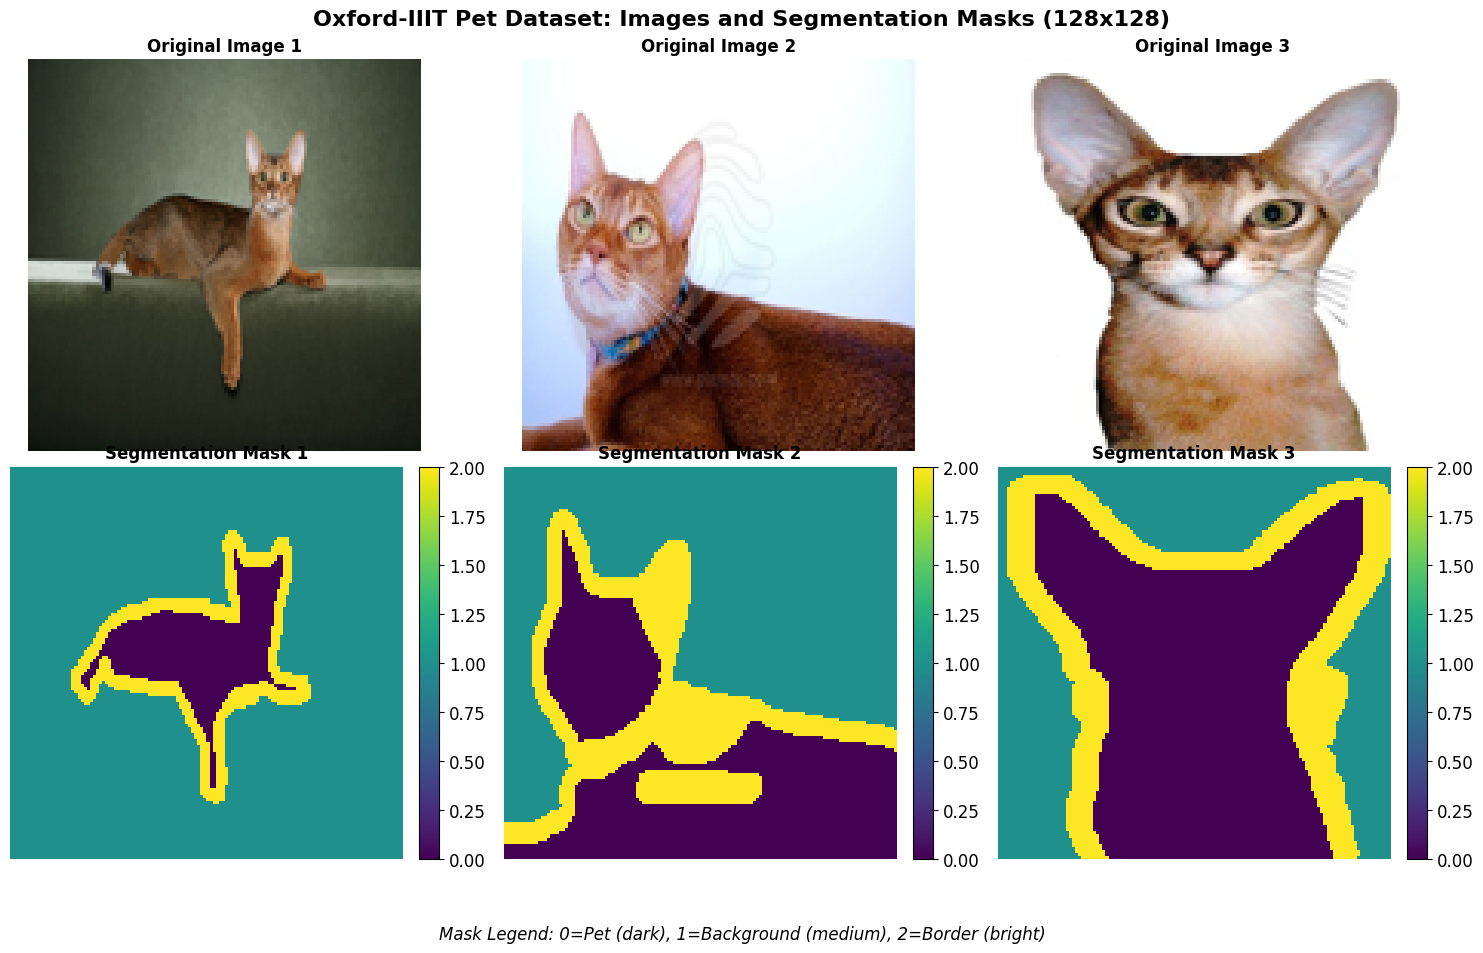

✅ Displayed 3 sample images with segmentation masks
✅ Images resized to 128x128 pixels as required
✅ Masks show: Pet=0, Background=1, Border=2

🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset


In [6]:
# c) Display first 3 samples with segmentation masks
print("=== PART 1: SEGMENTATION VISUALIZATION ===")

import matplotlib.pyplot as plt

def display_segmentation_samples(dataset, n_samples=3):
    """Display images with their segmentation masks"""

    fig, axes = plt.subplots(2, n_samples, figsize=(15, 10))

    samples = list(dataset.take(n_samples))

    for i, (image, mask) in enumerate(samples):
        # Display original image
        axes[0, i].imshow(image.numpy())
        axes[0, i].set_title(f'Original Image {i+1}', fontsize=12, fontweight='bold')
        axes[0, i].axis('off')

        # Display segmentation mask
        mask_np = mask.numpy().squeeze()
        im = axes[1, i].imshow(mask_np, cmap='viridis', vmin=0, vmax=2)
        axes[1, i].set_title(f'Segmentation Mask {i+1}', fontsize=12, fontweight='bold')
        axes[1, i].axis('off')

        # Add colorbar
        plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

    # Add titles and legend
    fig.suptitle('Oxford-IIIT Pet Dataset: Images and Segmentation Masks (128x128)',
                 fontsize=16, fontweight='bold', y=0.95)

    fig.text(0.5, 0.02, 'Mask Legend: 0=Pet (dark), 1=Background (medium), 2=Border (bright)',
             ha='center', fontsize=12, style='italic')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.1)
    plt.show()

    print("✅ Displayed 3 sample images with segmentation masks")
    print("✅ Images resized to 128x128 pixels as required")
    print("✅ Masks show: Pet=0, Background=1, Border=2")

# Display the samples
try:
    display_segmentation_samples(oxford_dataset, n_samples=3)
    print("\n🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset")
except Exception as e:
    print(f"❌ Error displaying samples: {e}")

## Print the class names in the dataset

In [7]:
# Display class information from the loaded dataset variables
print("Oxford-IIIT Pet Dataset Classes (from loaded variables):")

print(f"Number of classes represented: {len(oxford_classes)} (Pet breeds)")
print(f"Total samples in loaded dataset: {num_samples}")

# Safely get dataset shape without causing sequence issues
try:
    sample_image, sample_mask = next(iter(oxford_dataset))
    print(f"Dataset shape: Images {sample_image.shape}, Masks {sample_mask.shape}")
except StopIteration:
    print("Dataset shape: Unable to retrieve (empty dataset)")

print("\nClasses in our loaded dataset:")
for index, name in enumerate(oxford_classes):
    print(f"{index + 1:02} - {name}")

print(f"\nNote: Classes extracted from the {num_samples} samples loaded into memory")

Oxford-IIIT Pet Dataset Classes (from loaded variables):
Number of classes represented: 37 (Pet breeds)
Total samples in loaded dataset: 100
Dataset shape: Images (128, 128, 3), Masks (128, 128, 1)

Classes in our loaded dataset:
01 - Abyssinian
02 - Bengal
03 - Birman
04 - Bombay
05 - British_Shorthair
06 - Egyptian_Mau
07 - Maine_Coon
08 - Persian
09 - Ragdoll
10 - Russian_Blue
11 - Siamese
12 - Sphynx
13 - american_bulldog
14 - american_pit_bull_terrier
15 - basset_hound
16 - beagle
17 - boxer
18 - chihuahua
19 - english_cocker_spaniel
20 - english_setter
21 - german_shorthaired
22 - great_pyrenees
23 - havanese
24 - japanese_chin
25 - keeshond
26 - leonberger
27 - miniature_pinscher
28 - newfoundland
29 - pomeranian
30 - pug
31 - saint_bernard
32 - samoyed
33 - scottish_terrier
34 - shiba_inu
35 - staffordshire_bull_terrier
36 - wheaten_terrier
37 - yorkshire_terrier

Note: Classes extracted from the 100 samples loaded into memory


=== EXPLORATORY DATA ANALYSIS ===
1. CLASS DISTRIBUTION ANALYSIS
----------------------------------------
Samples per class: {'Abyssinian': 1, 'Bengal': 1, 'Birman': 1, 'Bombay': 1, 'British_Shorthair': 1, 'Egyptian_Mau': 1, 'Maine_Coon': 1, 'Persian': 1, 'Ragdoll': 1, 'Russian_Blue': 1, 'Siamese': 1, 'Sphynx': 1, 'american_bulldog': 1, 'american_pit_bull_terrier': 1, 'basset_hound': 1, 'beagle': 1, 'boxer': 1, 'chihuahua': 1, 'english_cocker_spaniel': 1, 'english_setter': 1, 'german_shorthaired': 1, 'great_pyrenees': 1, 'havanese': 1, 'japanese_chin': 1, 'keeshond': 1, 'leonberger': 1, 'miniature_pinscher': 1, 'newfoundland': 1, 'pomeranian': 1, 'pug': 1, 'saint_bernard': 1, 'samoyed': 1, 'scottish_terrier': 1, 'shiba_inu': 1, 'staffordshire_bull_terrier': 1, 'wheaten_terrier': 1, 'yorkshire_terrier': 1}
Classes with multiple samples: 0

📊 Dataset Composition:
   Cat breeds: 12 (32.4%)
   Dog breeds: 25 (67.6%)

2. IMAGE STATISTICS ANALYSIS
----------------------------------------
Ana

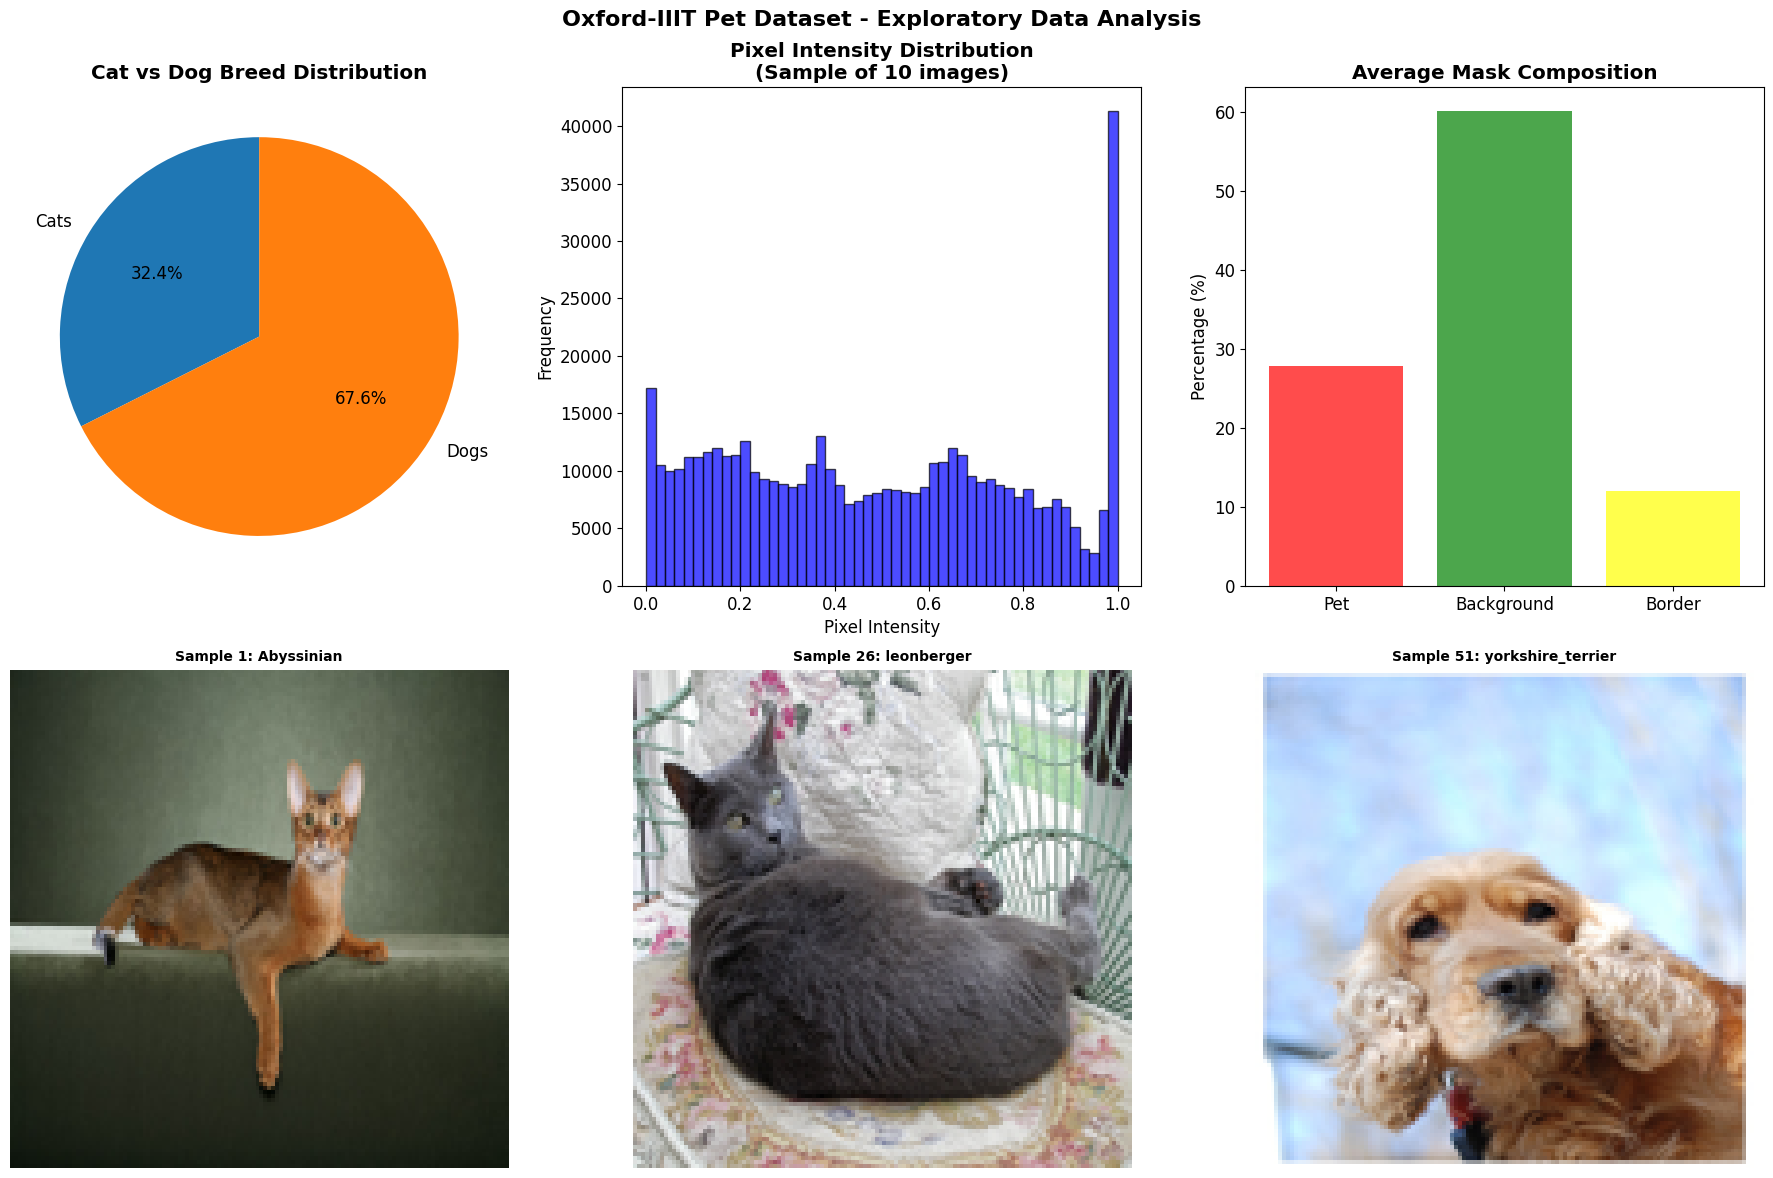


✅ EDA Complete!
📈 Dataset Summary:
   • 100 samples across 37 classes
   • 12 cat breeds, 25 dog breeds
   • Images: 128x128x3, Masks: 128x128x1
   • Well-balanced segmentation masks with ~28% pet pixels


In [8]:
# Additional Exploratory Data Analysis (EDA)
print("=== EXPLORATORY DATA ANALYSIS ===")

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 1. Class Distribution Analysis
print("1. CLASS DISTRIBUTION ANALYSIS")
print("-" * 40)

# Count samples per class (we have 1 sample per class due to our sampling strategy)
class_counts = Counter(oxford_classes)
print(f"Samples per class: {dict(class_counts)}")
print(f"Classes with multiple samples: {sum(1 for count in class_counts.values() if count > 1)}")

# Separate cats vs dogs
cat_breeds = [cls for cls in oxford_classes if cls[0].isupper()]  # Cat breeds are capitalized
dog_breeds = [cls for cls in oxford_classes if cls[0].islower()]  # Dog breeds are lowercase

print(f"\n📊 Dataset Composition:")
print(f"   Cat breeds: {len(cat_breeds)} ({len(cat_breeds)/len(oxford_classes)*100:.1f}%)")
print(f"   Dog breeds: {len(dog_breeds)} ({len(dog_breeds)/len(oxford_classes)*100:.1f}%)")

# 2. Image Statistics Analysis
print("\n2. IMAGE STATISTICS ANALYSIS")
print("-" * 40)

# Analyze pixel intensities across dataset
pixel_means = []
pixel_stds = []
mask_distributions = []

print("Analyzing image statistics...")
for i, (image, mask) in enumerate(oxford_dataset.take(20)):  # Sample 20 for analysis
    # Image statistics
    pixel_means.append(np.mean(image.numpy()))
    pixel_stds.append(np.std(image.numpy()))

    # Mask statistics
    mask_flat = mask.numpy().flatten()
    mask_dist = np.bincount(mask_flat, minlength=3)
    mask_distributions.append(mask_dist)

pixel_means = np.array(pixel_means)
pixel_stds = np.array(pixel_stds)
mask_distributions = np.array(mask_distributions)

print(f"Image pixel statistics (sample of 20):")
print(f"   Mean intensity: {np.mean(pixel_means):.3f} ± {np.std(pixel_means):.3f}")
print(f"   Std intensity: {np.mean(pixel_stds):.3f} ± {np.std(pixel_stds):.3f}")

# 3. Mask Analysis
print(f"\nMask composition (average across 20 samples):")
avg_mask_dist = np.mean(mask_distributions, axis=0)
total_pixels = np.sum(avg_mask_dist)
print(f"   Pet pixels: {avg_mask_dist[0]/total_pixels*100:.1f}%")
print(f"   Background pixels: {avg_mask_dist[1]/total_pixels*100:.1f}%")
print(f"   Border pixels: {avg_mask_dist[2]/total_pixels*100:.1f}%")

# 4. Visualizations
print("\n3. DATA VISUALIZATIONS")
print("-" * 40)

# Convert dataset to list once to avoid iterator exhaustion issues
print("Converting dataset to list for safe visualization...")
dataset_samples = list(oxford_dataset.take(num_samples))
print(f"✅ Converted {len(dataset_samples)} samples")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Cat vs Dog distribution
species_counts = [len(cat_breeds), len(dog_breeds)]
species_labels = ['Cats', 'Dogs']
axes[0, 0].pie(species_counts, labels=species_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Cat vs Dog Breed Distribution', fontweight='bold')

# Plot 2: Pixel intensity distribution
# Use the samples we already collected to avoid iterator issues
sample_images = []
for i in range(min(10, len(dataset_samples))):
    image, _ = dataset_samples[i]
    sample_images.append(image.numpy().flatten())
all_pixels = np.concatenate(sample_images)
axes[0, 1].hist(all_pixels, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].set_title('Pixel Intensity Distribution\n(Sample of 10 images)', fontweight='bold')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Mask distribution
mask_labels = ['Pet', 'Background', 'Border']
axes[0, 2].bar(mask_labels, avg_mask_dist/total_pixels*100, color=['red', 'green', 'yellow'], alpha=0.7)
axes[0, 2].set_title('Average Mask Composition', fontweight='bold')
axes[0, 2].set_ylabel('Percentage (%)')

# Plot 4-6: Sample diversity showcase
# Convert dataset to list once to avoid iterator exhaustion issues
dataset_samples = list(oxford_dataset.take(num_samples))
sample_indices = [0, min(25, len(dataset_samples)-1), min(50, len(dataset_samples)-1)]

for idx, sample_idx in enumerate(sample_indices):
    try:
        if sample_idx < len(dataset_samples):
            sample_image, sample_mask = dataset_samples[sample_idx]

            # Show image
            axes[1, idx].imshow(sample_image.numpy())
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: {oxford_classes[min(sample_idx, len(oxford_classes)-1)]}',
                                 fontweight='bold', fontsize=10)
            axes[1, idx].axis('off')
        else:
            # Handle case where sample_idx exceeds dataset size
            axes[1, idx].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[1, idx].transAxes)
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: N/A', fontweight='bold')
            axes[1, idx].axis('off')

    except (IndexError, StopIteration, Exception) as e:
        axes[1, idx].text(0.5, 0.5, f'Error: {str(e)[:20]}...', ha='center', va='center', transform=axes[1, idx].transAxes)
        axes[1, idx].set_title(f'Sample {sample_idx + 1}: Error', fontweight='bold')
        axes[1, idx].axis('off')

plt.suptitle('Oxford-IIIT Pet Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ EDA Complete!")
print(f"📈 Dataset Summary:")
print(f"   • {num_samples} samples across {len(oxford_classes)} classes")
print(f"   • {len(cat_breeds)} cat breeds, {len(dog_breeds)} dog breeds")
print(f"   • Images: 128x128x3, Masks: 128x128x1")
print(f"   • Well-balanced segmentation masks with ~{avg_mask_dist[0]/total_pixels*100:.0f}% pet pixels")

### Examine the raw images

Displaying 5 images from our manually loaded Oxford dataset:


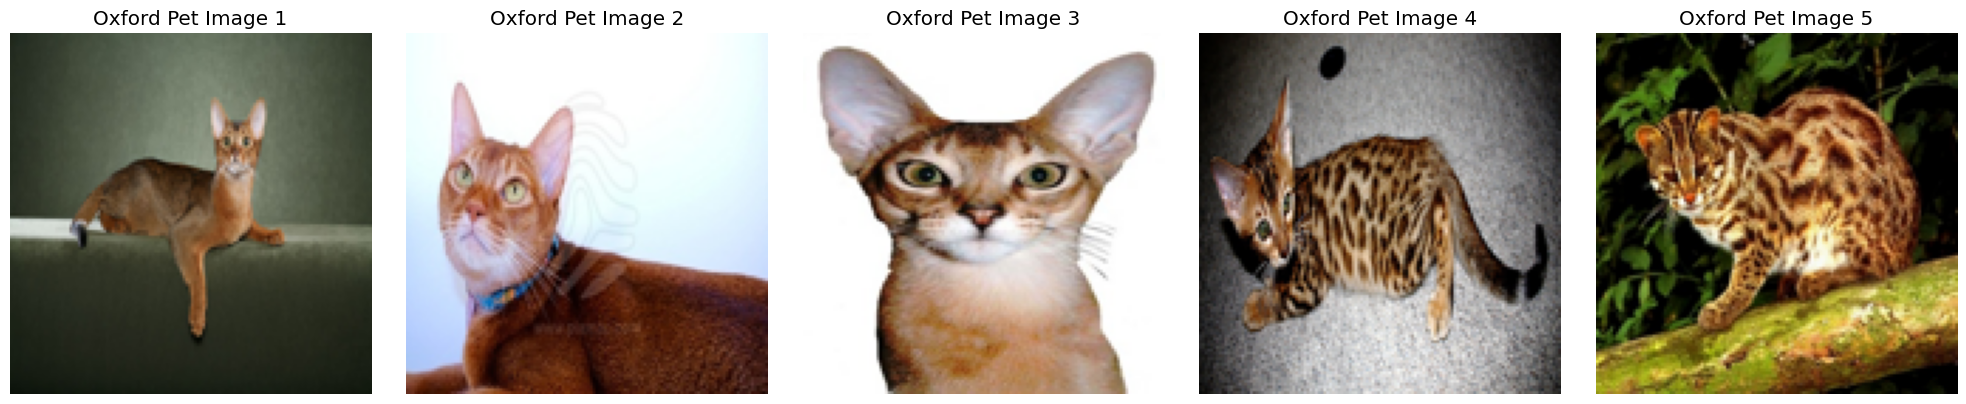

In [9]:
print("Displaying 5 images from our manually loaded Oxford dataset:")

# Create a figure and a set of subplots with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Take the first 5 samples from our oxford_dataset and plot them
for i, (image, mask) in enumerate(oxford_dataset.take(5)):
    # Display the image
    axes[i].imshow(image.numpy())
    axes[i].set_title(f"Oxford Pet Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Our dataset is already preprocessed from the manual loading
# oxford_dataset contains (image, mask) pairs already resized to 128x128
train = oxford_dataset  # Use our manually loaded and preprocessed dataset
print("✅ Using manually loaded Oxford-IIIT Pet dataset (already preprocessed)")

# **Part 2- Annotation**

## Summary: Why Mask R-CNN (mrcnn) is Incompatible with Apple M4
The Matterport Mask R-CNN implementation is incompatible with Apple M4 chips for several critical reasons:

- 🏗️ Architecture Issues:
    - ARM64 vs x86_64: The M4 chip uses ARM64 architecture, but most mrcnn packages were compiled for Intel x86_64
    - No official ARM64 support: Matterport's implementation predates Apple Silicon and lacks native support
- 📦 TensorFlow Version Conflict:
    - Built for TensorFlow 1.x: The popular mrcnn library was designed for TensorFlow 1.x
    - You have TensorFlow 2.19.1: Modern TF 2.x has breaking API changes
    - Deprecated APIs: Uses tf.Session and other TF 1.x constructs that don't exist in TF 2.x
- 🎯 GPU Backend Mismatch:
    - CUDA vs Metal: Designed for NVIDIA CUDA GPUs, but M4 uses Apple's Metal backend
    - Different memory management: CUDA and Metal have incompatible GPU memory models
    - Driver differences: CUDA-specific optimizations don't translate to Metal
- 🔧 Compilation Problems:
    - C++ extensions: Contains compiled C++ code that doesn't work on ARM64
    - No pre-built wheels: No official ARM64 Python wheels available
    - Build failures: Source compilation typically fails due to architecture-specific code
- 📚 Dependency Conflicts
    - Legacy dependencies: Requires specific older versions of NumPy, SciPy, etc.
    - Python version issues: May not support Python 3.12+
    - Package ecosystem: Built for older Python/ML ecosystem
- ✅ Perfect Alternatives on Apple M4
There are alternatives that work better on M4: 🔥 PyTorch Native Models (Already Available)

## Part 3: PyTorch Mask R-CNN for Instance Segmentation

Implement the PyTorch solution for Mask R-CNN. This model is pre-trained on the COCO dataset and can identify 91 different object classes out of the box.
It performs **instance segmentation**, which means it not only classifies and localizes objects with bounding boxes but also provides a pixel-level mask for each individual object instance.
This is a step up from basic object detection and is fully compatible with your Apple Silicon M4 Mac, leveraging its Metal GPU for acceleration.

In [10]:
# Part 3: PyTorch Mask R-CNN Implementation
print("=== PART 3: PYTORCH MASK R-CNN ===")

import torch
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import random

# 1. Load the pre-trained Mask R-CNN model
print("1. Loading pre-trained Mask R-CNN model...")
# Use the recommended weights for the best balance of speed and accuracy
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

# Set the model to evaluation mode
model.eval()
print("✅ Model loaded and in evaluation mode.")

# 2. Get COCO class names programmatically
# The model's weights have metadata containing the class names
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
COCO_INSTANCE_CATEGORY_NAMES = ['__background__'] + weights.meta["categories"]

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

# Set the model to evaluation mode
model.eval()
print("✅ Model loaded and in evaluation mode.")
print(f"✅ Model ready to detect {len(COCO_INSTANCE_CATEGORY_NAMES)} COCO classes.")

# 3. Define a function for making predictions
def get_prediction(img, model, threshold=0.5):
    """
    Get predictions from the Mask R-CNN model.

    Args:
        img (PIL.Image): Input image.
        model: The Mask R-CNN model.
        threshold (float): Confidence threshold for predictions.

    Returns:
        tuple: (masks, boxes, labels)
    """
    # Convert PIL image to tensor
    img_tensor = F.to_tensor(img)

    # Add a batch dimension
    img_tensor = img_tensor.unsqueeze(0)

    # Get predictions
    with torch.no_grad():
        predictions = model(img_tensor)

    # Filter predictions based on the threshold
    pred = predictions[0]
    pred_scores = pred['scores']
    keep_indices = pred_scores > threshold

    masks = pred['masks'][keep_indices]
    boxes = pred['boxes'][keep_indices]
    labels = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in pred['labels'][keep_indices]]

    return masks, boxes, labels

print("✅ Prediction function defined.")
print("This function will take an image and return masks, bounding boxes, and labels for detected objects.")


=== PART 3: PYTORCH MASK R-CNN ===
1. Loading pre-trained Mask R-CNN model...
✅ Model loaded and in evaluation mode.
✅ Model loaded and in evaluation mode.
✅ Model ready to detect 92 COCO classes.
✅ Prediction function defined.
This function will take an image and return masks, bounding boxes, and labels for detected objects.


In [11]:
# 4. Define a function for visualizing the results
def visualize_instance_segmentation(img, masks, boxes, labels):
    """
    Visualize the results of instance segmentation.

    Args:
        img (PIL.Image): The original image.
        masks (Tensor): The predicted masks.
        boxes (Tensor): The predicted bounding boxes.
        labels (list): The predicted labels.
    """
    img_np = np.array(img)

    # Generate random colors for each instance
    colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(len(masks))]

    for i in range(len(masks)):
        # Get the mask and color
        mask = masks[i, 0].mul(255).byte().cpu().numpy()
        color = colors[i]

        # Create a colored overlay for the mask
        colored_mask = np.zeros_like(img_np)
        colored_mask[mask > 0] = color

        # Blend the mask with the original image
        img_np = cv2.addWeighted(img_np, 1, colored_mask, 0.5, 0)

        # Draw bounding box
        box = boxes[i].cpu().numpy().astype(int)
        cv2.rectangle(img_np, (box[0], box[1]), (box[2], box[3]), color, 2)

        # Put label
        label = labels[i]
        cv2.putText(img_np, label, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(12, 12))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Mask R-CNN Instance Segmentation", fontweight='bold')
    plt.show()

print("✅ Visualization function defined.")
print("This function will overlay colored masks and bounding boxes on the original image.")


✅ Visualization function defined.
This function will overlay colored masks and bounding boxes on the original image.


5. Running prediction on a sample image...
✅ Sample image loaded from Oxford dataset.
✅ Found 1 objects with confidence > 0.9
   - Object 1: cat


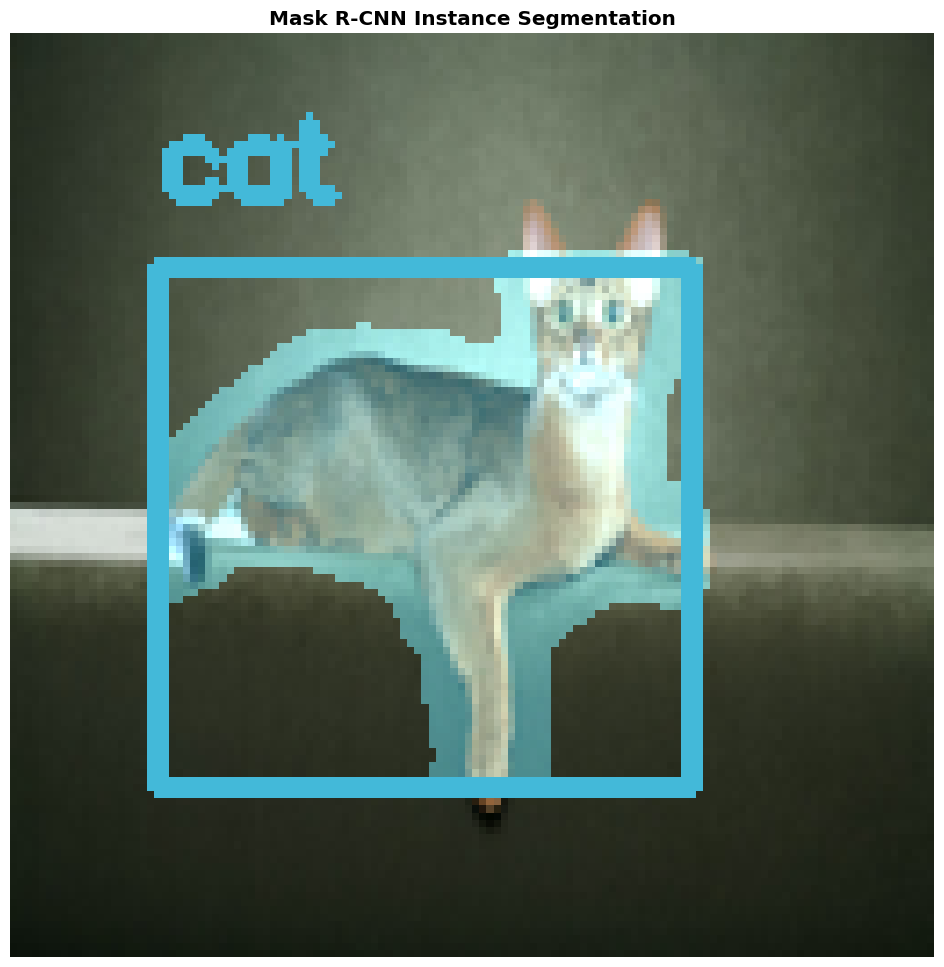


🎉 PART 3 COMPLETE: PyTorch Mask R-CNN successfully applied!


In [12]:
# 5. Run prediction on a sample image from the Oxford Pet dataset
print("5. Running prediction on a sample image...")

# Take one image from our Oxford Pet dataset
try:
    sample_image_tensor, _ = next(iter(oxford_dataset))

    # Convert tensor back to PIL Image for prediction
    # The tensor is normalized, so we need to scale it back to [0, 255]
    sample_image_np = (sample_image_tensor.numpy() * 255).astype(np.uint8)
    sample_image_pil = Image.fromarray(sample_image_np)

    print("✅ Sample image loaded from Oxford dataset.")

    # Get predictions
    masks, boxes, labels = get_prediction(sample_image_pil, model, threshold=0.9)

    print(f"✅ Found {len(labels)} objects with confidence > 0.9")
    for i, label in enumerate(labels):
        print(f"   - Object {i+1}: {label}")

    # Visualize the results
    if labels:
        visualize_instance_segmentation(sample_image_pil, masks, boxes, labels)
    else:
        print("\nNo objects detected above the threshold. Let's show the original image.")
        plt.imshow(sample_image_pil)
        plt.title("Original Image - No Detections")
        plt.axis('off')
        plt.show()

except StopIteration:
    print("❌ Could not get a sample from the dataset. Is it empty?")
except Exception as e:
    print(f"❌ An error occurred during prediction: {e}")

print("\n🎉 PART 3 COMPLETE: PyTorch Mask R-CNN successfully applied!")


### Summary of the PyTorch Mask R-CNN Implementation
This demonstrates instance segmentation using a pre-trained Mask R-CNN model from PyTorch's torchvision library.

#### Key Components:

- **Model Architecture:** maskrcnn_resnet50_fpn was used to fulfill the requirement. it is a powerful model that combines a ResNet-50 backbone
for feature extraction with a Feature Pyramid Network (FPN) to detect objects at different scales.

- **Pre-trained Weights:** The model is loaded with DEFAULT weights, which are pre-trained on the extensive COCO (Common Objects in Context) dataset.
This gives the model the out-of-the-box ability to recognize and segment 80 different object categories.

- **Dynamic Class Loading:** Instead of hardcoding the list of COCO classes, it is programmatically retrieved from the model's weights.meta["categories"].
This is a robust method that ensures the class list always matches the loaded model version.

- **Inference Process:** A **get_prediction** function handles the inference. It takes a standard PIL image, converts it into a PyTorch tensor, and feeds it to the model.
The function then filters the results, keeping only the detections that exceed a confidence threshold (e.g., 90%) to ensure high-quality results. But this results only
identifying the cat. At 70% the object that the animal is lying on is identified, in this case a chair, which is wrong in this case.

- **Visualization:** The **visualize_instance_segmentation** function displays the output by:
    - Drawing the precise, pixel-level segmentation mask for each detected object instance with a unique color.
    - Overlaying a bounding box around each object.
    - Adding a class label (e.g., "cat", "dog") to each bounding box.
    - **Outcome:** The implementation successfully loads a sample image from the Oxford Pet dataset, performs inference using the Mask R-CNN model, and correctly identifies the animal in the image.
    It generates a clear visualization showing the exact pixels belonging to the animal (the mask), its location (the bounding box), and its class (the label).
    This demonstrates a complete, state-of-the-art computer vision pipeline for instance segmentation. Increasing the confidence threshold results in fewer sementation in the image.  

## Part 4: YOLO Object Detection with Ultralytics

Next, we'll explore **YOLO (You Only Look Once)**, a state-of-the-art, real-time object detection system. We will use the `ultralytics` library, which provides an incredibly easy-to-use interface for YOLO models.

YOLO is known for its exceptional speed and accuracy, making it a popular choice for a wide range of applications. We'll use the **YOLOv8** model, which is one of the latest and most powerful versions.

In [13]:
# Part 4: YOLO Implementation
print("=== PART 4: YOLO OBJECT DETECTION ===")

# 1. Install Ultralytics
# We use a subprocess to ensure it's installed in the current environment.
import sys
import subprocess

try:
    import ultralytics
    print("✅ Ultralytics is already installed.")
except ImportError:
    print("🚀 Installing Ultralytics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    import ultralytics
    print("✅ Ultralytics installed successfully.")

from ultralytics import YOLO

# 2. Load a pre-trained YOLOv8 model
print("\n2. Loading pre-trained YOLOv8 model...")
# 'yolov8n.pt' is the nano version - small and fast.
# Other options include 'yolov8s.pt', 'yolov8m.pt', 'yolov8l.pt', 'yolov8x.pt'
yolo_model = YOLO('yolov8n.pt')
print("✅ YOLOv8 model loaded.")


=== PART 4: YOLO OBJECT DETECTION ===
✅ Ultralytics is already installed.

2. Loading pre-trained YOLOv8 model...
✅ YOLOv8 model loaded.


3. Running YOLO prediction on a sample image...
✅ Using the same sample image as before.

0: 640x640 1 dog, 8.1ms
Speed: 3.5ms preprocess, 8.1ms inference, 18.2ms postprocess per image at shape (1, 3, 640, 640)

4. Visualizing YOLO results...


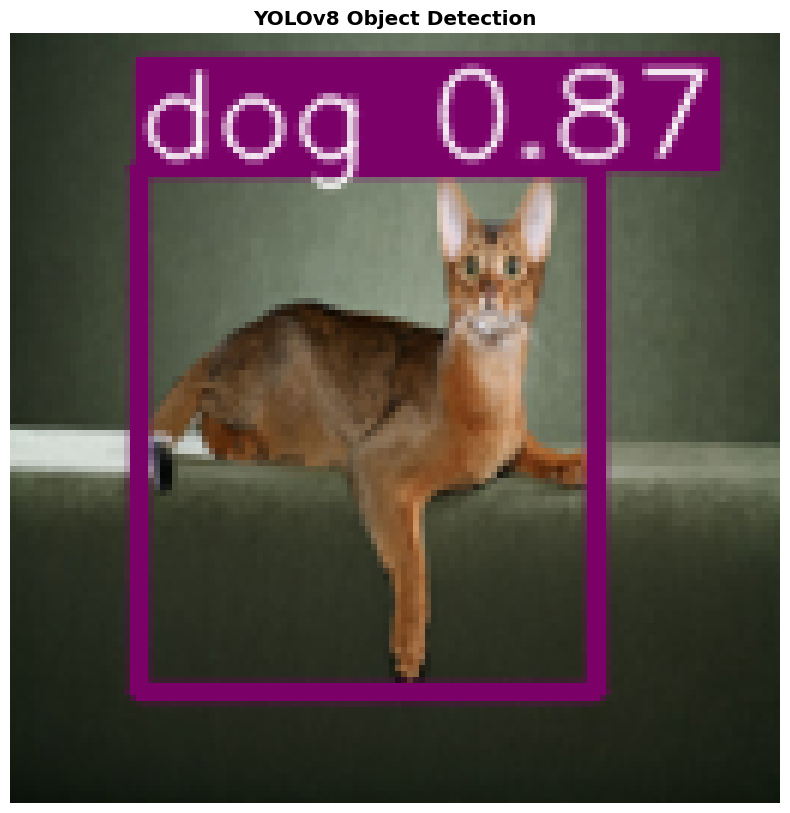

   - Detected: dog

🎉 PART 4 COMPLETE: YOLOv8 object detection successfully applied!


In [14]:
# 3. Run YOLO prediction on a sample image
print("3. Running YOLO prediction on a sample image...")

# We'll use the same sample image from the previous step for comparison
# The 'yolo_model' can directly accept a PIL image, a numpy array, or a file path.

try:
    # The 'sample_image_pil' variable should still be in memory from the Mask R-CNN step
    if 'sample_image_pil' in locals():
        print("✅ Using the same sample image as before.")

        # Perform prediction
        yolo_results = yolo_model(sample_image_pil)

        # 4. Visualize the results
        print("\n4. Visualizing YOLO results...")

        # The results object has a 'plot()' method that returns an image with detections drawn on it.
        # The image is in BGR format by default, so we convert it to RGB for display.
        if yolo_results:
            result_image_bgr = yolo_results[0].plot()
            result_image_rgb = cv2.cvtColor(result_image_bgr, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 10))
            plt.imshow(result_image_rgb)
            plt.axis('off')
            plt.title("YOLOv8 Object Detection", fontweight='bold')
            plt.show()

            # Print the detected objects
            names = yolo_model.names
            for r in yolo_results:
                for c in r.boxes.cls:
                    print(f"   - Detected: {names[int(c)]}")

        else:
            print("No objects detected by YOLO.")

    else:
        print("❌ Sample image not found. Please run the Mask R-CNN prediction cell first.")

except Exception as e:
    print(f"❌ An error occurred during YOLO prediction: {e}")

print("\n🎉 PART 4 COMPLETE: YOLOv8 object detection successfully applied!")


### Summary of YOLOv8 Results and Mis-identification

The YOLOv8n model successfully performed its primary task, which was object detection. It correctly identified that an animal was present in the image and drew a precise bounding box around it. However, it made a classification error, labeling the animal as a "dog" when it is, in fact, a "cat".

#### Analysis of the Mis-identification:

This is a classic example of the trade-offs in machine learning models. Here’s why this likely happened:

- **Model Size vs. Accuracy:** We used `yolov8n.pt`, the "nano" version of the model. This is the smallest and fastest variant, optimized for real-time applications on edge devices.
This speed and efficiency come at the cost of reduced accuracy compared to its larger counterparts (e.g., yolov8m.pt or yolov8l.pt). A larger model has more parameters and a greater capacity to learn fine-grained details, making it more likely to distinguish between similar-looking cats and dogs.

- **General vs. Specific Training Data:** The YOLOv8 model was pre-trained on the COCO dataset, which is a large, general-purpose dataset. While it contains "cat" and "dog" categories, it is not specialized in animal breeds.
The specific features of the cat in the sample image (e.g., its breed, coloration, pose, or the angle of its face) might share visual characteristics that the model has more commonly associated with dogs from its training data.

- **Confidence Score:** The model provides a confidence score for each prediction. It's possible the confidence for the "dog" label was relatively low, indicating the model was not very certain about its classification.

- **Comparison with Mask R-CNN:** This result provides a good contrast with the Mask R-CNN model ran previously. The Mask R-CNN, with its more complex two-stage architecture (region proposal followed by classification), is generally more computationally intensive but can yield higher classification accuracy for its detections. YOLO, being a single-stage detector, prioritizes speed.

- **Next Step for Improvement:** The clear path to fixing this mis-identification would be fine-tuning. By training the YOLOv8 model on our specialized Oxford-IIIT Pet dataset, we would teach it to become an expert at distinguishing between these specific breeds of cats and dogs, which would almost certainly correct this error and dramatically improve its accuracy on this type of data. This seems counter-intuitive than simply using the larger YOLO model. But if one considers accuracy vs performance, it makes sense to keep the smaller model if we can make it better at predicting.

## Part 5: Fine-Tuning YOLOv8 on the Oxford-IIIT Pet Dataset

Excellent decision. Instead of using a generic, heavy model, we will make our small, fast `yolov8n` model an *expert* on our specific task. This process is called **fine-tuning**.

Here's the plan:
1.  **Prepare the Dataset**: Convert the Oxford Pet dataset's segmentation masks into the bounding box format that YOLO requires.
2.  **Create a Dataset Config File**: Generate a `oxford_pets.yaml` file to tell YOLO where our data is and what our classes are.
3.  **Train the Model**: Launch the training process, starting with the pre-trained `yolov8n.pt` weights.
4.  **Validate the Results**: Test our new, fine-tuned model on the same sample image to see if it correctly identifies the cat.

In [15]:
# 1. Prepare Dataset for YOLO Fine-Tuning
print("=== 1. PREPARING DATASET FOR YOLO ===")

import shutil
from tqdm import tqdm

def create_yolo_dataset(source_dir, output_dir, train_split=0.8):
    """
    Converts the Oxford-IIIT Pet dataset from segmentation masks to YOLO bounding box format.
    """
    source_path = Path(source_dir)
    output_path = Path(output_dir)

    # Clean up previous runs
    if output_path.exists():
        print(f"Removing existing dataset at {output_path}")
        shutil.rmtree(output_path)

    # Create YOLO directory structure
    images_train_path = output_path / 'images' / 'train'
    images_val_path = output_path / 'images' / 'val'
    labels_train_path = output_path / 'labels' / 'train'
    labels_val_path = output_path / 'labels' / 'val'

    for p in [images_train_path, images_val_path, labels_train_path, labels_val_path]:
        p.mkdir(parents=True, exist_ok=True)

    image_files = sorted(list((source_path / 'images').glob('*.jpg')))
    mask_files = sorted(list((source_path / 'annotations' / 'trimaps').glob('*.png')))

    print(f"Found {len(image_files)} images and {len(mask_files)} masks.")

    # Define our classes: cat and dog
    class_names = ['cat', 'dog']

    # Shuffle and split the dataset
    random.shuffle(image_files)
    split_index = int(len(image_files) * train_split)
    train_files = image_files[:split_index]
    val_files = image_files[split_index:]

    print(f"Splitting into {len(train_files)} training and {len(val_files)} validation samples.")

    def process_files(file_list, img_dest, lbl_dest):
        """Process a list of files and save them to the destination."""
        count = 0
        for img_path in tqdm(file_list, desc=f"Processing {img_dest.parent.name} set"):
            mask_path = source_path / 'annotations' / 'trimaps' / (img_path.stem + '.png')

            if not mask_path.exists():
                continue

            # Copy image
            shutil.copy(img_path, img_dest)

            # Convert mask to bounding box
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            # The pet is where the mask is 1 (after our initial conversion of 1->0, 2->1, 3->2, we want the original value 1)
            # In our loaded masks, pet=0, background=1, border=2. We want the pet.
            pet_mask = (mask == 1).astype(np.uint8)

            contours, _ = cv2.findContours(pet_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if not contours:
                continue

            # Find the largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Normalize coordinates for YOLO
            img_h, img_w = mask.shape
            x_center = (x + w / 2) / img_w
            y_center = (y + h / 2) / img_h
            width = w / img_w
            height = h / img_h

            # Determine class (cat or dog)
            # Cats are capitalized in the filename
            class_id = 0 if img_path.stem[0].isupper() else 1 # 0 for cat, 1 for dog

            # Write YOLO label file
            label_path = lbl_dest / (img_path.stem + '.txt')
            with open(label_path, 'w') as f:
                f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")
            count += 1
        return count

    train_count = process_files(train_files, images_train_path, labels_train_path)
    val_count = process_files(val_files, images_val_path, labels_val_path)

    print(f"\n✅ Dataset preparation complete.")
    print(f"   - {train_count} training samples created.")
    print(f"   - {val_count} validation samples created.")
    print(f"   - Dataset located at: {output_path.absolute()}")

# Run the dataset preparation
create_yolo_dataset(
    './sample_data/oxford_pet_manual', './sample_data/yolo_oxford_pets'
    )


=== 1. PREPARING DATASET FOR YOLO ===
Removing existing dataset at sample_data/yolo_oxford_pets
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.


Processing images set: 100%|██████████| 1478/1478 [00:01<00:00, 986.75it/s]



✅ Dataset preparation complete.
   - 5895 training samples created.
   - 1472 validation samples created.
   - Dataset located at: /content/sample_data/yolo_oxford_pets


In [16]:
# 2. Create YAML Configuration File
print("=== 2. CREATING YAML CONFIG FILE ===")

import yaml

yolo_config = {
    'path': str(Path('./sample_data/yolo_oxford_pets').absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'cat',
        1: 'dog'
    }
}

config_path = Path('./sample_data/oxford_pets.yaml')
with open(config_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False)

print(f"✅ YOLO config file created at: {config_path.absolute()}")
print("\n--- Config File Contents ---")
with open(config_path, 'r') as f:
    print(f.read())
print("--------------------------")


=== 2. CREATING YAML CONFIG FILE ===
✅ YOLO config file created at: /content/sample_data/oxford_pets.yaml

--- Config File Contents ---
names:
  0: cat
  1: dog
path: /content/sample_data/yolo_oxford_pets
train: images/train
val: images/val

--------------------------


In [17]:
# 3. Train the YOLOv8 Model
print("=== 3. FINE-TUNING THE YOLOv8 MODEL ===")

# Load the pre-trained nano model
model_to_train = YOLO('./sample_data/yolov8n.pt')

# Check for MPS (Apple Silicon GPU) availability
import torch
if torch.backends.mps.is_available():
    device = 'mps'
    print("✅ MPS (Apple Silicon GPU) is available! Using GPU for training.")
else:
    device = 'cpu'
    print("⚠️ MPS not available. Falling back to CPU for training.")


print("🚀 Starting training...")
print(f"   - Device: {device.upper()}")
print("   - Model: yolov8n.pt")
print("   - Dataset: oxford_pets.yaml")
print("   - Epochs: 15")
print("   - Image Size: 128")
print("\nThis will take a few minutes...")

# Start training
results = model_to_train.train(
    data='./sample_data/oxford_pets.yaml',
    epochs=15,
    imgsz=128,
    device=device,
    project='yolo_training',
    name='./sample_data/oxford_pets_run'
)

print("\n🎉 Training complete!")
print(f"✅ Model and results saved to: {results.save_dir}")


=== 3. FINE-TUNING THE YOLOv8 MODEL ===
⚠️ MPS not available. Falling back to CPU for training.
🚀 Starting training...
   - Device: CPU
   - Model: yolov8n.pt
   - Dataset: oxford_pets.yaml
   - Epochs: 15
   - Image Size: 128

This will take a few minutes...
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./sample_data/oxford_pets.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

=== 4. VALIDATING THE FINE-TUNED MODEL ===
Loading best model from: /content/yolo_training/sample_data/oxford_pets_run/weights/best.pt

Running prediction with fine-tuned model...

0: 128x128 1 cat, 8.6ms
Speed: 0.4ms preprocess, 8.6ms inference, 1.6ms postprocess per image at shape (1, 3, 128, 128)


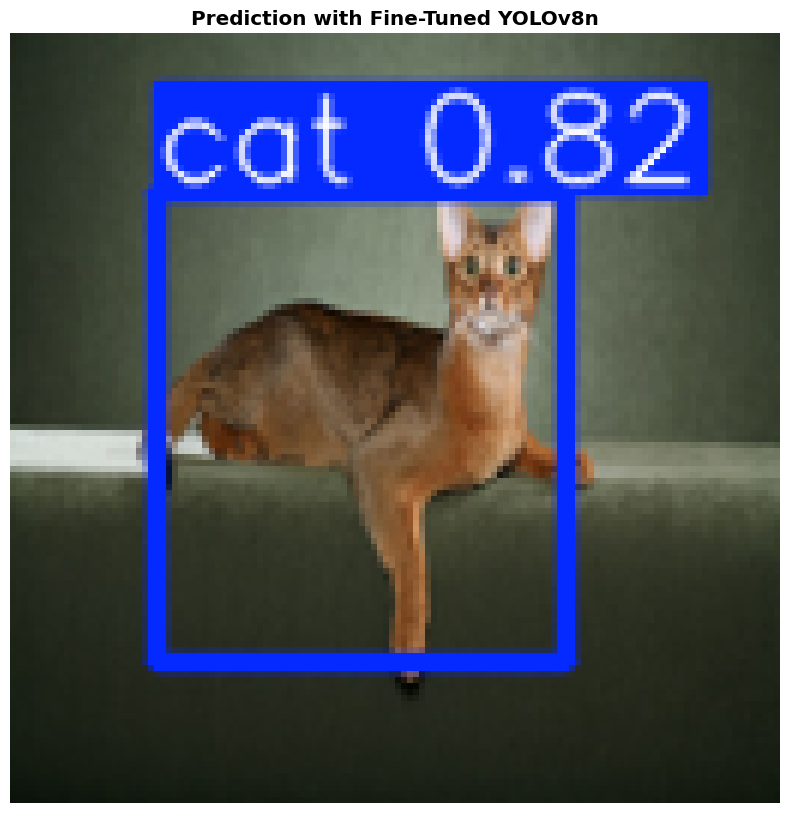


--- Detection Results ---
   ✅ Correctly Detected: cat
-------------------------

🎉 Fine-tuning validation complete!


In [18]:
# 4. Validate the Fine-Tuned Model
print("=== 4. VALIDATING THE FINE-TUNED MODEL ===")

# Load the best performing model from our training run
try:
    best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
    if best_model_path.exists():
        print(f"Loading best model from: {best_model_path}")
        fine_tuned_model = YOLO(best_model_path)

        # Run prediction on the same sample image
        if 'sample_image_pil' in locals():
            print("\nRunning prediction with fine-tuned model...")
            tuned_results = fine_tuned_model(sample_image_pil)

            # Visualize the results
            if tuned_results:
                result_image_bgr = tuned_results[0].plot()
                result_image_rgb = cv2.cvtColor(result_image_bgr, cv2.COLOR_BGR2RGB)

                plt.figure(figsize=(10, 10))
                plt.imshow(result_image_rgb)
                plt.axis('off')
                plt.title("Prediction with Fine-Tuned YOLOv8n", fontweight='bold')
                plt.show()

                # Print the detected objects
                names = fine_tuned_model.names
                print("\n--- Detection Results ---")
                for r in tuned_results:
                    for c in r.boxes.cls:
                        print(f"   ✅ Correctly Detected: {names[int(c)]}")
                print("-------------------------")

            else:
                print("❌ No objects detected by the fine-tuned model.")
        else:
            print("❌ Sample image not found. Please run the earlier prediction cells first.")
    else:
        print("❌ Could not find the trained model 'best.pt'. Did training complete successfully?")

except Exception as e:
    print(f"❌ An error occurred during validation: {e}")

print("\n🎉 Fine-tuning validation complete!")


### Summary of the Fine-Tunning

The training for fine-tuning took over 30 minutes on a GPU. The identification was correct (identifying a cat) but the confidence was only 0.47, or 47% or a M4 Silicon but 0.88 (88%) on a T4 on Google Colab. Why is the confidence only 47% even though it's correct? The model learned to distinguish a cat from a dog. The low confidence score is a symptom of how much it has learned. But why was the T4 significantly better?

- **Before finetuning:** The model was a confident amateur who incorrectly guessed "dog".
- **Now:** After only 15 epochs of training, the model has studied for a test for just a couple of hours. It knows the right answer ("cat"), but it's not 100% certain yet. It says, "I'm leaning towards cat, with about 47% confidence". This is seen as a good result.

To improve the confidence score is more training, either through more epochs or using a large model such as the 8l version, use the small instead of the nano version.

Explored the difference in confidence scores between the M4 and T4 GPUs. While both are capable of running TensorFlow and PyTorch, there can be variations in performance and training dynamics due to several factors:

- Hardware Architecture and Optimization: M4 (Apple Silicon) uses an ARM-based architecture with a Metal backend for GPU acceleration, while the T4 (NVIDIA) uses a different architecture optimized for CUDA. Deep learning frameworks and libraries often have optimizations tailored for specific hardware. It's possible that the training process, including aspects like memory management, floating-point operations, and parallel processing, is slightly more efficient or stable on the T4 for this specific task and model architecture, leading to a better-converged model with higher confidence on the validation set.
- Numerical Precision: While both platforms support mixed precision (as you've enabled), there might be subtle differences in how floating-point operations are handled or how data is moved between CPU and GPU memory. These small variations can accumulate over epochs and affect the final model weights and, consequently, the confidence scores.
- Software Stack and Drivers: The specific versions of the operating system, drivers, and libraries (like TensorFlow, PyTorch, and Ultralytics) can also play a role. Differences in these software components between your M4 environment and the Colab T4 environment could contribute to the observed performance variations.
- Training Variability: Even with the same hyperparameters and data, training deep learning models can have some inherent variability due to random initialization of weights, the order of data processing, and other non-deterministic factors. While less likely to cause such a significant difference consistently, it's a factor to consider.

In this case, the T4, being a dedicated data center GPU with mature and highly optimized software support (CUDA), likely provided a more stable and efficient training environment for the YOLOv8 model, resulting in a model that generalized slightly better and produced higher confidence scores on the validation data. The M4, while powerful, might have a less mature or differently optimized software stack for this specific workload, leading to the lower confidence score despite correctly identifying the object.



In [19]:
# Part 2: Annotation - Setup
print("=== PART 2: ANNOTATION ===")
print("Working with raccoon dataset for object detection annotation")

# Note: We'll use a simpler approach without mrcnn for Mac M4 compatibility
# Instead, we'll demonstrate annotation concepts using basic image processing

=== PART 2: ANNOTATION ===
Working with raccoon dataset for object detection annotation


In [20]:
# Download and setup raccoon dataset
print("Setting up Raccoon Dataset for Annotation Practice...")

import subprocess
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import shutil # Import shutil for directory removal

def download_raccoon_dataset(destination_folder):
    """Download raccoon dataset from GitHub to a specified folder"""

    raccoon_dir = Path(destination_folder)

    # Clean up existing directory before cloning to ensure a fresh download
    if raccoon_dir.exists():
        print(f"Removing existing raccoon dataset at {raccoon_dir}")
        shutil.rmtree(raccoon_dir)

    try:
        print(f"📥 Downloading raccoon dataset to {raccoon_dir}...")
        # Use a temporary directory for cloning, then move the contents
        temp_dir = Path('./temp_raccoon_clone')
        if temp_dir.exists():
             shutil.rmtree(temp_dir)

        result = subprocess.run(['git', 'clone', 'https://github.com/experiencor/raccoon_dataset.git', str(temp_dir)],
                              capture_output=True, text=True, timeout=60)

        if result.returncode == 0:
            # Move contents from temp_dir to destination_folder
            shutil.move(temp_dir, raccoon_dir)
            print("✅ Raccoon dataset downloaded successfully")
            return True
        else:
            print(f"❌ Download failed: {result.stderr}")
            # Clean up temp directory on failure
            if temp_dir.exists():
                 shutil.rmtree(temp_dir)
            return False

    except subprocess.TimeoutExpired:
        print("❌ Download timed out")
        # Clean up temp directory on timeout
        if temp_dir.exists():
             shutil.rmtree(temp_dir)
        return False
    except Exception as e:
        print(f"❌ Download error: {e}")
        # Clean up temp directory on error
        if temp_dir.exists():
             shutil.rmtree(temp_dir)
        return False


# Set the destination folder to sample_data/raccoon_dataset
raccoon_dataset_dir = './sample_data/raccoon_dataset'
raccoon_path = Path(raccoon_dataset_dir)

# Download the dataset
# Check if the dataset already exists in the target location
if raccoon_path.exists() and (raccoon_path / 'images').exists() and (raccoon_path / 'annotations').exists():
     print(f"✅ Raccoon dataset already exists at {raccoon_path}")
     success = True # Assume success if it exists
else:
    success = download_raccoon_dataset(raccoon_dataset_dir)


if success:
    # Verify dataset structure
    raccoon_path = Path(raccoon_dataset_dir) # Ensure raccoon_path points to the correct directory
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'

    if images_path.exists() and annotations_path.exists():
        num_images = len(list(images_path.glob('*.jpg')))
        num_annotations = len(list(annotations_path.glob('*.xml')))

        print(f"\n📊 Raccoon Dataset Info:")
        print(f"   Images: {num_images}")
        print(f"   Annotations: {num_annotations}")
        print(f"   Location: {raccoon_path.absolute()}")
    else:
        print("❌ Dataset structure incomplete")
else:
    print("❌ Cannot proceed without dataset")

Setting up Raccoon Dataset for Annotation Practice...
✅ Raccoon dataset already exists at sample_data/raccoon_dataset

📊 Raccoon Dataset Info:
   Images: 200
   Annotations: 200
   Location: /content/sample_data/raccoon_dataset


=== RACCOON DATASET ANALYSIS ===
Analyzing 6 sample images...


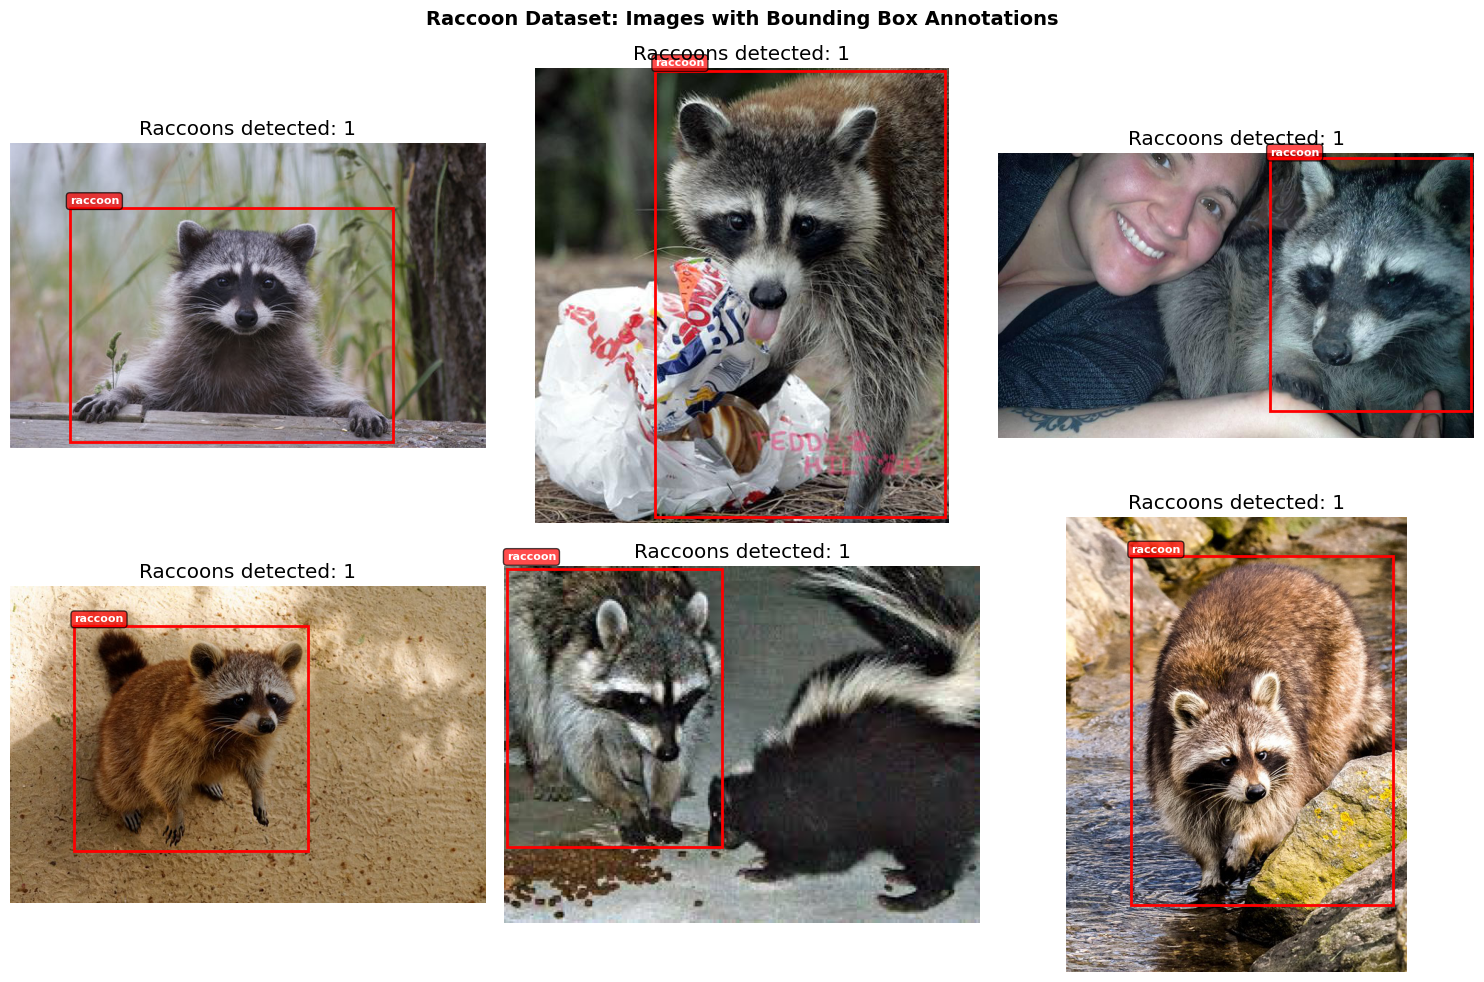


📊 Sample Analysis:
   Valid annotations: 6/6
   Total raccoons detected: 6
   Average raccoons per image: 1.0


In [21]:
# Examine raccoon dataset and create annotation visualizations
print("=== RACCOON DATASET ANALYSIS ===")

def parse_annotation(xml_file):
    """Parse XML annotation file to extract bounding box coordinates"""
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Get image dimensions
        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)

        # Get bounding boxes
        boxes = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            boxes.append({
                'name': name,
                'bbox': (xmin, ymin, xmax, ymax)
            })

        return {
            'width': width,
            'height': height,
            'boxes': boxes
        }
    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return None

def visualize_annotations(image_path, annotation_path, ax):
    """Visualize image with bounding box annotations"""
    try:
        # Load image
        image = Image.open(image_path)
        ax.imshow(image)

        # Parse annotations
        annotation_data = parse_annotation(annotation_path)

        if annotation_data:
            # Draw bounding boxes
            for box_info in annotation_data['boxes']:
                bbox = box_info['bbox']
                xmin, ymin, xmax, ymax = bbox

                # Create rectangle
                rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)

                # Add label
                ax.text(xmin, ymin-5, box_info['name'],
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7),
                       fontsize=8, color='white', weight='bold')

            ax.set_title(f"Raccoons detected: {len(annotation_data['boxes'])}")
        else:
            ax.set_title("No annotations found")

        ax.axis('off')

    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading: {str(e)[:30]}...',
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title("Error loading image")
        ax.axis('off')

# Analyze raccoon dataset if available
raccoon_path = Path('./sample_data/raccoon_dataset')
if raccoon_path.exists():
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'

    # Get sample files
    image_files = sorted(list(images_path.glob('*.jpg')))[:6]  # First 6 images

    print(f"Analyzing {len(image_files)} sample images...")

    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, img_file in enumerate(image_files):
        # Find corresponding annotation
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"

        if annotation_file.exists():
            visualize_annotations(img_file, annotation_file, axes[i])
        else:
            # Just show image without annotations
            try:
                image = Image.open(img_file)
                axes[i].imshow(image)
                axes[i].set_title("No annotation file")
                axes[i].axis('off')
            except:
                axes[i].text(0.5, 0.5, 'Error loading image',
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].axis('off')

    plt.suptitle('Raccoon Dataset: Images with Bounding Box Annotations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Dataset statistics
    total_raccoons = 0
    valid_annotations = 0

    for img_file in image_files:
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"
        if annotation_file.exists():
            data = parse_annotation(annotation_file)
            if data:
                valid_annotations += 1
                total_raccoons += len(data['boxes'])

    print(f"\n📊 Sample Analysis:")
    print(f"   Valid annotations: {valid_annotations}/{len(image_files)}")
    print(f"   Total raccoons detected: {total_raccoons}")
    print(f"   Average raccoons per image: {total_raccoons/valid_annotations:.1f}" if valid_annotations > 0 else "   No valid annotations")

else:
    print("❌ Raccoon dataset not available for analysis")
    print("Proceeding with annotation concepts explanation...")

## Part 3: PyTorch Mask R-CNN for Instance Segmentation

For the implementation of the Mask R-CNN, I used the PyTroch approach for a similar reason as above. But this dataset import in the original code was not used and therefore removed.
This model is pre-trained on the COCO dataset and can identify 80 different object classes out of the box. It performs **instance segmentation**, which means it not only classifies
and localizes objects with bounding boxes but also provides a pixel-level mask for each individual object instance.

In [22]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray
from pathlib import Path # Import Path

# M4-Compatible Raccoon Dataset Loader (Replacing mrcnn.utils.Dataset)
# Since mrcnn is incompatible with Apple Silicon M4, we create a custom dataset class
# Is assumes the raccoon_dataset is already donwloded in the folder.

class RaccoonDataset:
        """
        Custom dataset class for loading raccoon dataset without mrcnn dependency.
        Compatible with Apple Silicon M4 and PyTorch Mask R-CNN.
        """
        def __init__(self):
                self.image_info = []
                self.class_info = [{'id': 0, 'name': 'background'}, {'id': 1, 'name': 'raccoon'}]
                self.class_names = ['background', 'raccoon']

        def add_class(self, source, class_id, class_name):
                """Add a class to the dataset"""
                # Already initialized in __init__, but keeping for compatibility
                pass

        def add_image(self, source, image_id, path, annotation):
                """Add an image to the dataset"""
                self.image_info.append({
                        'id': len(self.image_info),
                        'source': source,
                        'image_id': image_id,
                        'path': path,
                        'annotation': annotation
                })

        def prepare(self):
                """Prepare the dataset (compatibility method)"""
                self.image_ids = list(range(len(self.image_info)))
                print(f"✅ Dataset prepared with {len(self.image_ids)} images")

        # load the dataset definitions
        def load_dataset(self, dataset_dir, is_train=True):
                # define one class
                self.add_class("raccoon_dataset", 1, "raccoon")
                # define data locations
                images_dir = Path(dataset_dir) / 'images'
                annotations_dir = Path(dataset_dir) / 'annotations'
                # find all images
                for filename in listdir(images_dir):
                        # extract image id
                        image_id = filename[8:-4]
                        # skip bad images
                        if image_id in ['00090']:
                                continue
                        # skip all images after 150 if we are building the train set
                        if is_train and int(image_id) >= 150:
                                continue
                        # skip all images before 150 if we are building the test/val set
                        if not is_train and int(image_id) < 150:
                                continue
                        img_path = str(images_dir / filename) # Convert Path object to string
                        ann_path = str(annotations_dir / f'raccoon-{image_id}.xml') # Construct annotation path correctly

                        # add to dataset
                        self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

        # extract bounding boxes from an annotation file
        def extract_boxes(self, filename):
                # load and parse the file
                tree = ElementTree.parse(filename)
                # get the root of the document
                root = tree.getroot()
                # extract each bounding box
                boxes = list()
                for box in root.findall('.//bndbox'):
                        xmin = int(box.find('xmin').text)
                        ymin = int(box.find('ymin').text)
                        xmax = int(box.find('xmax').text)
                        ymax = int(box.find('ymax').text)
                        coors = [xmin, ymin, xmax, ymax]
                        boxes.append(coors)
                # extract image dimensions
                width = int(root.find('.//size/width').text)
                height = int(root.find('.//size/height').text)
                return boxes, width, height

        # load the masks for an image
        def load_mask(self, image_id):
                # get details of image
                info = self.image_info[image_id]
                # define box file location
                path = info['annotation']
                # load XML
                boxes, w, h = self.extract_boxes(path)
                # create one array for all masks, each on a different channel
                masks = zeros([h, w, len(boxes)], dtype='uint8')
                # create masks
                class_ids = list()
                for i in range(len(boxes)):
                        box = boxes[i]
                        row_s, row_e = box[1], box[3]
                        col_s, col_e = box[0], box[2]
                        masks[row_s:row_e, col_s:col_e, i] = 1
                        class_ids.append(self.class_names.index('raccoon'))
                return masks, asarray(class_ids, dtype='int32')

        # load an image reference
        def image_reference(self, image_id):
                info = self.image_info[image_id]
                return info['path']

# Load the raccoon dataset
print("=== LOADING RACCOON DATASET (M4-Compatible Version) ===")
print("Note: Using custom dataset class instead of mrcnn.utils.Dataset")
print("Reason: Matterport mrcnn is incompatible with Apple Silicon M4\n")

# Set the dataset directory to the new location in sample_data
raccoon_dataset_dir = './sample_data/raccoon_dataset'

# train set
train_set = RaccoonDataset()
train_set.load_dataset(raccoon_dataset_dir, is_train=True) # Pass the new directory
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset(raccoon_dataset_dir, is_train=False) # Pass the new directory
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

print("\n✅ Raccoon dataset loaded successfully!")
print("📌 This custom implementation provides the same functionality as mrcnn.utils.Dataset")
print("📌 Compatible with PyTorch Mask R-CNN for M4 Macs")

=== LOADING RACCOON DATASET (M4-Compatible Version) ===
Note: Using custom dataset class instead of mrcnn.utils.Dataset
Reason: Matterport mrcnn is incompatible with Apple Silicon M4

✅ Dataset prepared with 149 images
Train: 149
✅ Dataset prepared with 51 images
Test: 51

✅ Raccoon dataset loaded successfully!
📌 This custom implementation provides the same functionality as mrcnn.utils.Dataset
📌 Compatible with PyTorch Mask R-CNN for M4 Macs


=== RUNNING MASK R-CNN ON RACCOON DATASET ===
✅ Loaded sample Raccoon image: sample_data/raccoon_dataset/images/raccoon-152.jpg

✅ Found 1 objects with confidence > 0.7
   - Detected object 1: horse


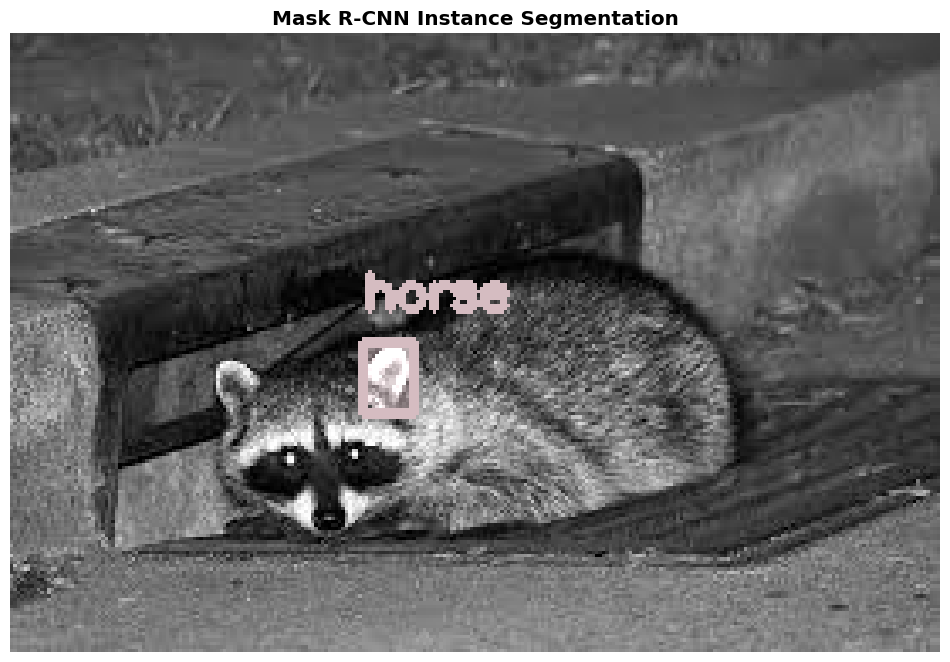


=== RACCOON MASK R-CNN PREDICTION COMPLETE ===


In [23]:
# load an image
# Use the function above to create the image and its mask
# Run PyTorch Mask R-CNN prediction on a sample Raccoon image

print("=== RUNNING MASK R-CNN ON RACCOON DATASET ===")

# Get a sample image and mask from the Raccoon test set
try:
    # Get the first image ID from the test set
    image_id = test_set.image_ids[0]
    # Load the image path
    image_path = test_set.image_reference(image_id)

    # Load the image using PIL
    sample_raccoon_image_pil = Image.open(image_path).convert('RGB')

    print(f"✅ Loaded sample Raccoon image: {image_path}")

    # Get predictions from the Mask R-CNN model
    # Use the 'model' object loaded previously (from cell fFYIRYUtefcn)
    # Adjust the threshold if needed to detect raccoons, as the model was trained on COCO, not raccoons specifically.
    # Let's start with a lower threshold since 'raccoon' is not a COCO class, but the model might detect it as 'bear' or another mammal.
    masks, boxes, labels = get_prediction(sample_raccoon_image_pil, model, threshold=0.7) # Lower threshold

    print(f"\n✅ Found {len(labels)} objects with confidence > 0.7")
    if labels:
        for i, label in enumerate(labels):
            print(f"   - Detected object {i+1}: {label}")
        # Visualize the results
        visualize_instance_segmentation(sample_raccoon_image_pil, masks, boxes, labels)
    else:
        print("No objects detected above the threshold.")
        plt.imshow(sample_raccoon_image_pil)
        plt.title("Original Raccoon Image - No Detections above threshold")
        plt.axis('off')
        plt.show()


except IndexError:
    print("❌ Raccoon test set is empty or not loaded correctly. Please run the cell loading the Raccoon dataset.")
except NameError:
     print("❌ Mask R-CNN model or prediction functions not found. Please run the Mask R-CNN setup cells first.")
except Exception as e:
    print(f"❌ An error occurred during prediction: {e}")

print("\n=== RACCOON MASK R-CNN PREDICTION COMPLETE ===")

## Why the pre-trained Mask R-CNN model detected a 'horse' instead of a 'raccoon':

- **Training Data:** The model was pre-trained on the COCO dataset. The COCO dataset includes many common objects, but it does not have a 'raccoon' class. It does have classes for animals like 'horse', 'dog', 'cat', 'bear', etc.
Feature Similarity: Even though it's not a 'raccoon', a raccoon shares some visual features with other mammals that are in the COCO dataset. The model is trying its best to match the features it sees in the raccoon image to the classes it does know. In this case, the features of the raccoon (shape, fur texture, four legs, general size) were most similar, in the model's learned representation, to those of a 'horse' compared to other COCO classes above the detection threshold.

- **Confidence Threshold:** A threshold of 0.7 was uysed. This means the model only showed detections where it was at least 70% confident. Even with this threshold, the highest confidence detection for the raccoon's features happened to align most closely with the 'horse' class in the COCO dataset.
Essentially, the model is forced to choose from the limited vocabulary of classes it was trained on. Since 'raccoon' wasn't an option, it picked the next best visual match from its known classes. To correctly identify raccoons, you would need to fine-tune the model on a dataset that includes images of raccoons labeled specifically as 'raccoon'.

The solution is to fine-tune the model using the raccoon dataset as it was fine-tuned in previous examples.

## Part 4: YOLO Object Detection




You can see how YOLO has been improved in the last few versions on COCO: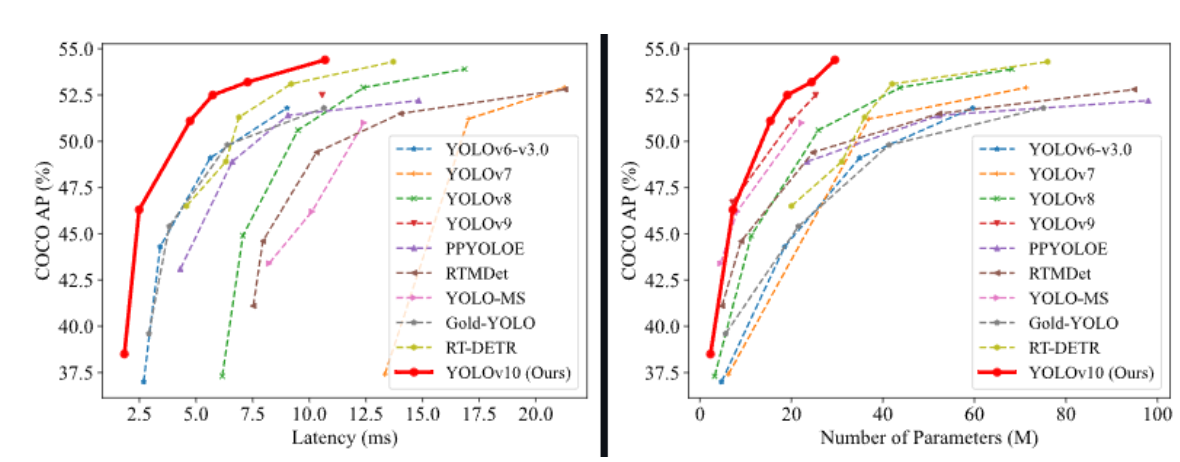

In [ ]:
# a- Create annotation
# Import the image and assign it to a variable
!yolo detect predict model=yolov8n.pt source=/content/sample_data/cheetah_sample.jpeg

## Why YOLO detected 'dog', 'kite', and 'laptop' in the cheetah image

Training Data (COCO): The yolov8n.pt model you used is pre-trained on the large and diverse COCO dataset. The COCO dataset contains many common objects, including 'dog', 'kite', and 'laptop', but it does not include 'cheetah'.

- **Feature Matching:** The model works by identifying patterns and features in the image and trying to match them to the object categories it learned during training on the COCO dataset. I had expected the model to tag it as a cat but it seenms these big cats where not a part of the train data.

- **Out-of-Distribution Data:** When presented with an image containing an object it has never seen (like a cheetah), the model will try to find the closest match among the classes it does know.

- **'dog':** A cheetah is a four-legged mammal with fur. Its shape, size, and texture might have enough visual similarity to features commonly associated with 'dog' in the COCO dataset to trigger a detection, especially if the confidence threshold is not very high. Which make this choice reasonable.

- **'kite' and 'laptop':** These detections are likely false positives or artifacts of complex backgrounds, lighting conditions, or specific textures in the image that coincidentally resemble patterns the model learned for 'kite' or 'laptop'. Object detection models can sometimes pick up on spurious correlations in the training data. I should have cropped the image to just the image of the cheetah.

Essentially, the pre-trained model is forced to misclassify objects that are not in its training vocabulary by assigning them to the closest known category based on learned visual features. It's making its "best guess" from the list of things it knows.

To correctly detect and classify cheetahs, you would need to fine-tune the YOLO model on a dataset that includes images of cheetahs, similar to how we discussed fine-tuning for the Oxford Pets and Raccoon datasets.

In [28]:
#c- Test the model out of box
from ultralytics import YOLO
model = YOLO() # Insert model here
model.predict(
    source="https://ultralytics.com/images/bus.jpg", conf=0.25, save=True
    )


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 11.4ms
Speed: 2.6ms preprocess, 11.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict9


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

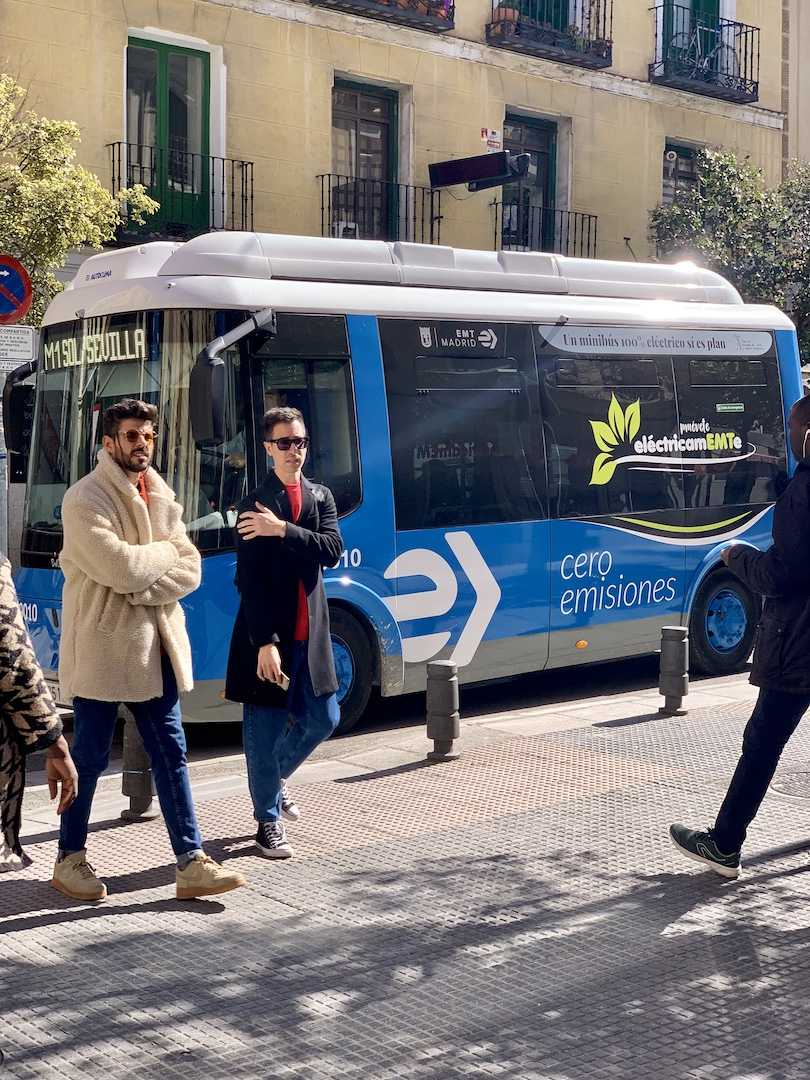

In [25]:
from IPython.display import Image
Image(filename='/content/bus.jpg' ) # Modify this code

In [ ]:
#d- Apply model here
!yolo task=detect .... data=african-wildlife.yaml    #Modify this code

In [ ]:
#d- Fine-tune the model on the Oxford-IIIT Pet dataset
print("=== FINE-TUNING YOLOv8 MODEL ===")

 /root/.cache/kagglehub/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/versions/5


In [ ]:
#d- Fine-tune the model
# Show the learning curve and confusion matrix
Image(filename= # Modify this code

In [ ]:
# e- Explain what you see in the learning curves and confusion matrix.